<a href="https://colab.research.google.com/github/Erike-Simon/EvoRNN-Project/blob/main/EvoRNN_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


**Programa de Pós-Graduação em Engenharia da Computação - PPGEC UPE**

**Aluno:** *Erike Simon Costa Cativo do Nascimento*

Experimentos do artigo "Uma Abordagem Evolucionária para Treinamento de Elman Networks na Modelagem de Séries Temporais"



---



#### Obteção e tratamento dos dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url_rec = "https://raw.githubusercontent.com/domingos108/hybrid_system_forecast/master/dataset/baseRECIFE.xlsx"
url_for = "https://raw.githubusercontent.com/domingos108/hybrid_system_forecast/master/dataset/baseFortaleza.xlsx"
url_nat = "https://raw.githubusercontent.com/domingos108/hybrid_system_forecast/master/dataset/BaseNatal.xlsx"

df_rec = pd.read_excel(url_rec)
df_for = pd.read_excel(url_for)
df_nat = pd.read_excel(url_nat)

##### Análises base Recife

In [ ]:
df_rec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  144 non-null    int64  
 1   Target      144 non-null    float64
 2   ARIMA       144 non-null    float64
 3   ARIMAX      144 non-null    float64
 4   SPLIT       144 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 5.8+ KB


In [ ]:
df_rec.describe()

,Unnamed: 0,Target,ARIMA,ARIMAX
count,144.000000,144.000000,144.000000,144.000000
mean,71.500000,2.119913,2.168661,2.155282
std,41.713307,0.426137,0.331190,0.348289
min,0.000000,1.064516,1.236068,0.975823
25%,35.750000,1.797590,1.925432,1.891576
50%,71.500000,2.156224,2.142119,2.210553
75%,107.250000,2.465833,2.430487,2.429479
max,143.000000,2.872864,2.791146,2.729043


**Estacionariedade**

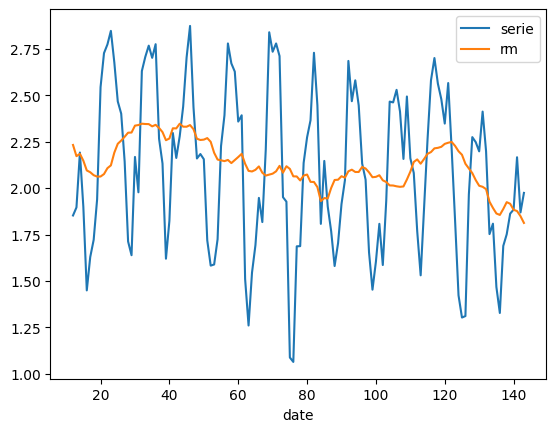

In [ ]:
# Função média móvel
def show_tend(ts, rm_size):
  df_show = pd.DataFrame()
  df_show['serie'] = ts.values[rm_size:]
  df_show['rm'] = ts.rolling(rm_size).mean().values[rm_size:]

  df_show['date'] = ts.index.to_list()[rm_size:]
  df_show.set_index('date', inplace=True)
  df_show.plot()
  plt.show()

ts_rec = df_rec['Target']
rm_size = 12
show_tend(ts_rec, rm_size)

Funções de autocorrelação (ACF) e autocorrelação parcial (PACF)

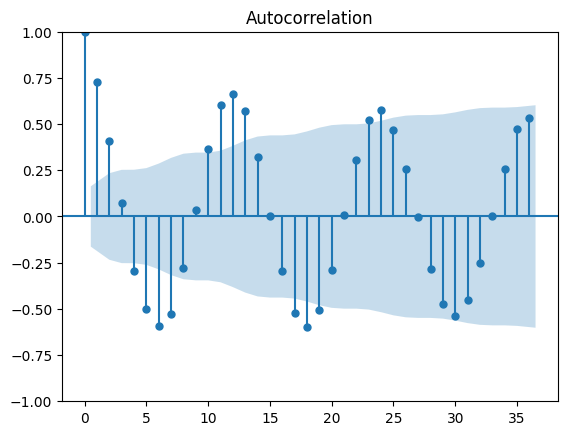

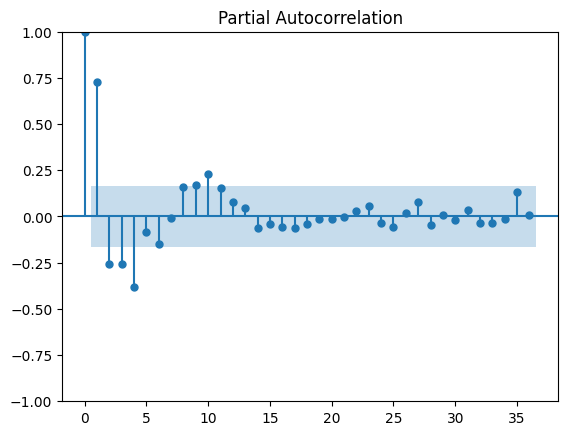

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_rec, lags=36)
plt.show()
plot_pacf(ts_rec, lags=36)
plt.show()

Teste de estacionariedade **KPSS**

In [ ]:
from statsmodels.tsa.stattools import kpss

stat_rec, p_value_rec, lags_rec, crit_rec = kpss(ts_rec, regression='c')

print("BASE RECIFE\n")
print(f"KPSS Statistic: {round(stat_rec, 2)}")
print(f"p-value: {round(p_value_rec, 2)}")
print("Nº de lags: ",round(lags_rec, 2))
print("\nValores críticos:\n")
for chave, valor in crit_rec.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE RECIFE

KPSS Statistic: 0.33
p-value: 0.1
Nº de lags:  6

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


C:\Users\Erike Simon\AppData\Local\Temp\ipykernel_1572\1963459826.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_rec, p_value_rec, lags_rec, crit_rec = kpss(ts_rec, regression='c')


O KPSS é outro teste para verificar a estacionariedade de uma série temporal. As hipóteses nula e alternativa do teste KPSS são opostas às do teste ADF:

- H₀ (nula): o processo é estacionário em termos de tendência [se p > 0.05]

- H₁ (alternativa): a série tem raiz unitária (não é estacionária) [se p =< 0.05]

-> `KPSS Statistic = 0.33` é menor do que todos os valores críticos (1, 3 e 10%).

-> `p-value = 0.1 > 0.05` -> há evidência de que a série é estacionária, não necessitando de diferenciação.

Teste **ADF** (Dickey-Fuller)

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Teste ADF na coluna Target
resultado = adfuller(ts_rec)

print("BASE RECIFE\n")
print("ADF Statistic:", round(resultado[0], 2))
print("p-value:", round(resultado[1], 2))
print("Nº de lags:", resultado[2])
print("Nº de observações:", resultado[3])
print("Valores críticos:")
for chave, valor in resultado[4].items():
    print(f"   {chave}: {valor}")

BASE RECIFE

ADF Statistic: -1.45
p-value: 0.56
Nº de lags: 10
Nº de observações: 133
Valores críticos:
   1%: -3.480500383888377
   5%: -2.8835279559405045
   10%: -2.578495716547007


O teste **ADF** verifica se a série possui raiz unitária, isto é, se ela é não estacionária.
As hipóteses são:

- H₀ (nula): a série tem raiz unitária (ou seja, não é estacionária) [se p > 0.05]

- H₁ (alternativa): a série não tem raiz unitária (ou seja, é estacionária) [se p=< 0.05]

-> `ADF Statistic = -1.45` é mais alto (menos negativo) do que todos os valores críticos (1, 3 e 10%).

-> `p-value = 0.557 > 0.05` (não rejeitamos H₀, ou seja, **a serie é não estacionária**)

*p-values* **KPSS** e **ADF** discordam, indicando que a série é estacionária em termos de tendência. Essa tendência precisa ser removida para tornar a série estritamente estacionária.

Podemos aplicar a diferenciação e reaplicar os testes.

Plot da série após a diferenciação

<Axes: >

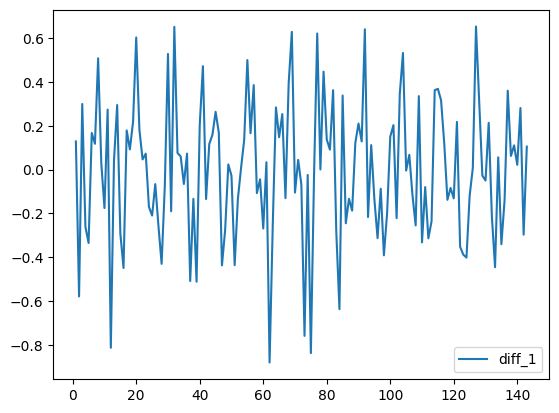

In [ ]:
df_diff_rec = pd.DataFrame()
df_diff_rec['diff_1'] = ts_rec.diff().iloc[1:]

df_diff_rec.plot()

Funções de autocorrelação (ACF) e autocorrelação parcial (PACF) (PÓS DIFERENCIAÇÃO)

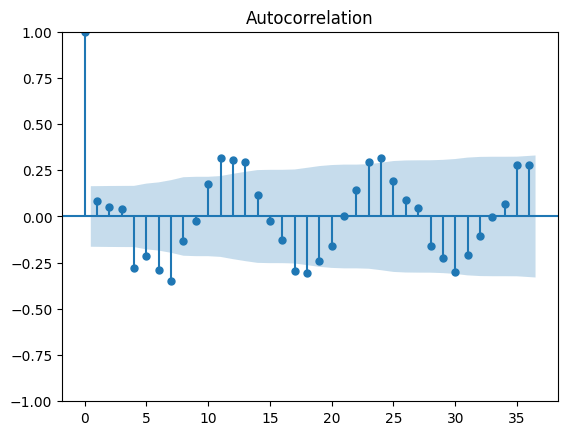

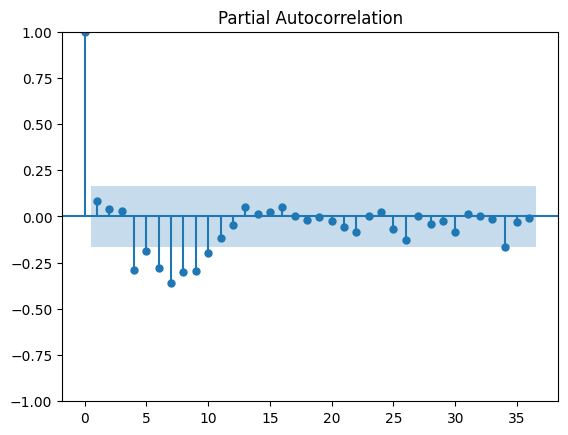

In [ ]:
ts_rec = df_diff_rec['diff_1']
plot_acf(ts_rec, lags=36)
plt.show()
plot_pacf(ts_rec, lags=36)
plt.show()

Existe de fato uma tendência de sazonalidade mais pronunciada pela ACF.

Teste de estacionariedade **KPSS** (pós diferenciação)

In [ ]:
stat_rec, p_value_rec, lags_rec, crit_rec = kpss(ts_rec, regression='c')

print("BASE RECIFE (série diferenciada)\n")
print(f"KPSS Statistic: {round(stat_rec, 2)}")
print(f"p-value: {round(p_value_rec, 2)}")
print("Nº de lags: ",round(lags_rec, 2))
print("\nValores críticos:\n")
for chave, valor in crit_rec.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE RECIFE (série diferenciada)

KPSS Statistic: 0.01
p-value: 0.1
Nº de lags:  3

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


C:\Users\Erike Simon\AppData\Local\Temp\ipykernel_1572\2089004432.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_rec, p_value_rec, lags_rec, crit_rec = kpss(ts_rec, regression='c')


Teste **ADF** (pós diferenciação)

In [ ]:
# Teste ADF na coluna Target
resultado = adfuller(ts_rec)

print("BASE RECIFE (série diferenciada)\n")
print("ADF Statistic:", round(resultado[0], 2))
print("p-value:", round(resultado[1], 2))
print("Nº de lags:", resultado[2])
print("Nº de observações:", resultado[3])
print("\nValores críticos:\n")
for chave, valor in resultado[4].items():
    print(f"   {chave}: {valor}")

BASE RECIFE (série diferenciada)

ADF Statistic: -8.18
p-value: 0.0
Nº de lags: 10
Nº de observações: 132

Valores críticos:

   1%: -3.4808880719210005
   5%: -2.8836966192225284
   10%: -2.5785857598714417


DESCREVER RESULTADOS APÓS DIFERENCIAÇÃO DA SÉRIE RECIFE

##### Análises base Fortaleza

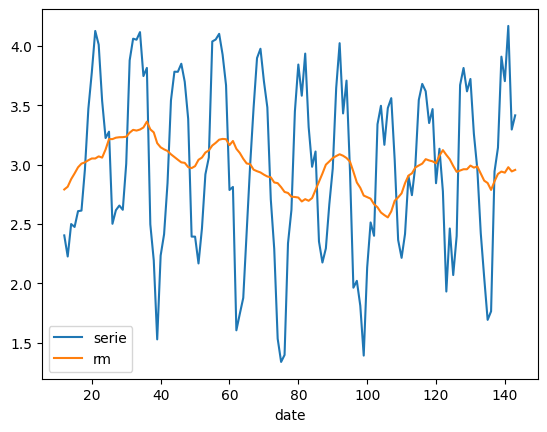

In [ ]:
ts_for = df_for['Target']
rm_size = 12
show_tend(ts_for, rm_size)

Funções de autocorrelação (ACF) e autocorrelação parcial (PACF)

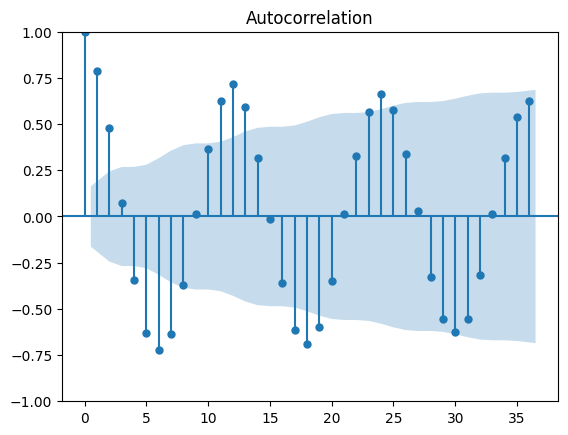

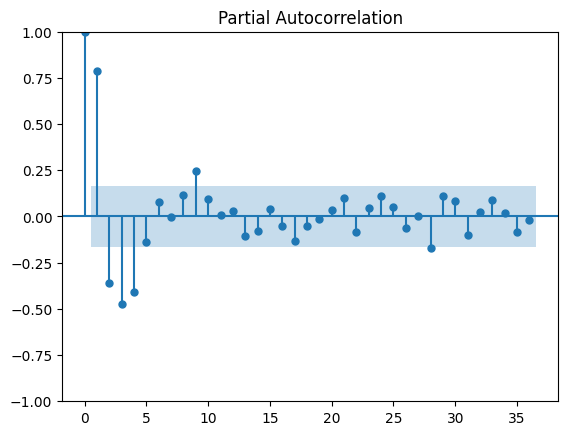

In [ ]:
plot_acf(ts_for, lags=36)
plt.show()
plot_pacf(ts_for, lags=36)
plt.show()

Teste de estacionariedade **KPSS**

In [ ]:
stat_for, p_value_for, lags_for, crit_for = kpss(ts_for, regression='c')

print("BASE FORTALEZA\n")
print(f"KPSS Statistic: {round(stat_for, 2)}")
print(f"p-value: {round(p_value_for, 2)}")
print("Nº de lags: ",round(lags_for, 2))
print("\nValores críticos:\n")
for chave, valor in crit_for.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE FORTALEZA

KPSS Statistic: 0.05
p-value: 0.1
Nº de lags:  6

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


-> `KPSS Statistic = 0.05` é menor do que todos os valores críticos.

-> `p-value = 0.1 > 0.05` -> há evidência de que a série é estacionária, não necessitando de diferenciação.

Teste **ADF**

In [ ]:
resultado_for = adfuller(ts_for)

print("BASE FORTALEZA\n")
print("ADF Statistic:", resultado_for[0])
print("p-value:", resultado_for[1])
print("Nº de lags:", resultado_for[2])
print("Nº de observações:", resultado_for[3])
print("Valores críticos:")
for chave, valor in resultado_for[4].items():
    print(f"   {chave}: {valor}")

BASE FORTALEZA

ADF Statistic: -2.6649650355657295
p-value: 0.080299519735617
Nº de lags: 9
Nº de observações: 134
Valores críticos:
   1%: -3.480118600110386
   5%: -2.8833618426136196
   10%: -2.578407034974382


-> `ADF Statistic = -2.66` é mais alto (menos negativo) do que todos o valor crítico 1 e 5%.

-> `p-value = 0.08 > 0.05` (não rejeitamos H₀, ou seja, **a serie é não estacionária**)

*p-values* **KPSS** e **ADF** discordam.

Podemos aplicar a diferenciação e reaplicar os testes.

<Axes: >

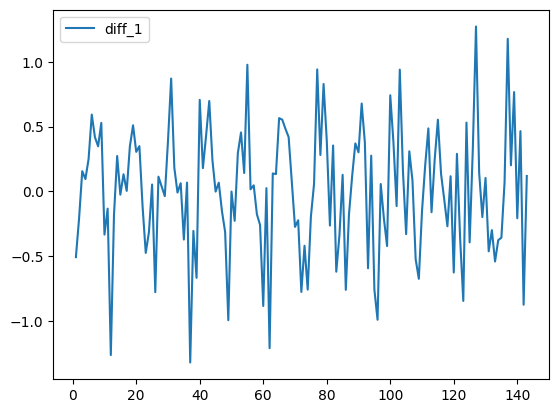

In [ ]:
df_diff_for = pd.DataFrame()
df_diff_for['diff_1'] = ts_for.diff().iloc[1:]

df_diff_for.plot()

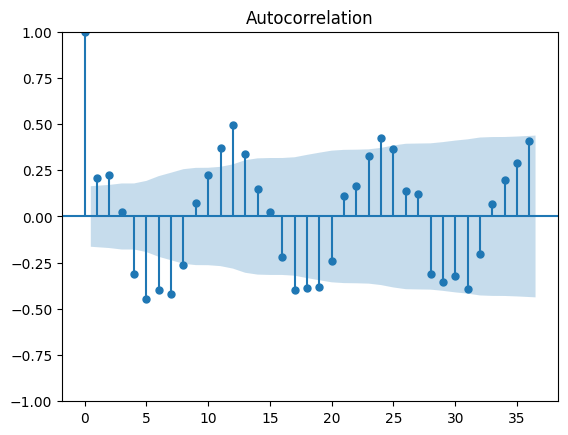

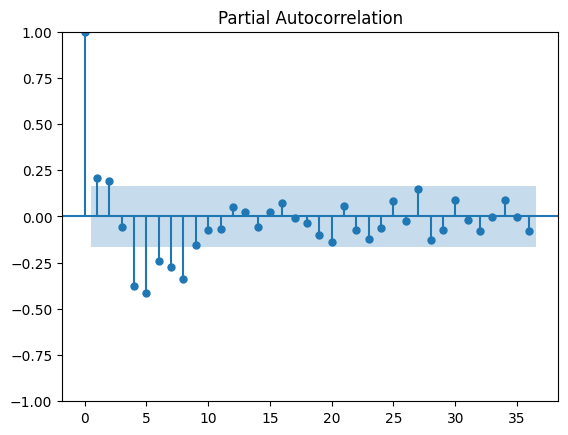

In [ ]:
ts_for = df_diff_for['diff_1']
plot_acf(ts_for, lags=36)
plt.show()
plot_pacf(ts_for, lags=36)
plt.show()

Teste de estacionariedade **KPSS** (pós diferenciação)

In [ ]:
stat_for, p_value_for, lags_for, crit_for = kpss(ts_for, regression='c')

print("BASE FORTALEZA\n")
print(f"KPSS Statistic: {round(stat_for, 2)}")
print(f"p-value: {round(p_value_for, 2)}")
print("Nº de lags: ",round(lags_for, 2))
print("\nValores críticos:\n")
for chave, valor in crit_for.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE FORTALEZA

KPSS Statistic: 0.01
p-value: 0.1
Nº de lags:  5

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


<ipython-input-34-f19d7b0685b8>:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_for, p_value_for, lags_for, crit_for = kpss(ts_for, regression='c')


Teste **ADF** (pós diferenciação)

In [ ]:
resultado_for = adfuller(ts_for)

print("BASE FORTALEZA\n")
print("ADF Statistic:", resultado_for[0])
print("p-value:", resultado_for[1])
print("Nº de lags:", resultado_for[2])
print("Nº de observações:", resultado_for[3])
print("Valores críticos:")
for chave, valor in resultado_for[4].items():
    print(f"   {chave}: {valor}")

BASE FORTALEZA

ADF Statistic: -10.15070861386846
p-value: 7.965091950003509e-18
Nº de lags: 8
Nº de observações: 134
Valores críticos:
   1%: -3.480118600110386
   5%: -2.8833618426136196
   10%: -2.578407034974382


DESCREVER OS RESULTADOS POSTERIORMENTE

##### Análises base Natal

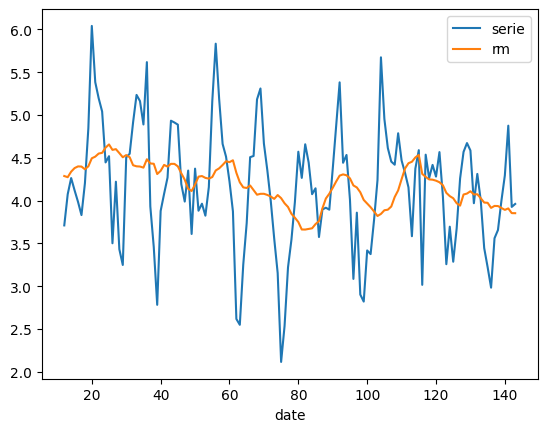

In [ ]:
ts_nat = df_nat['Target']
rm_size = 12
show_tend(ts_nat, rm_size)

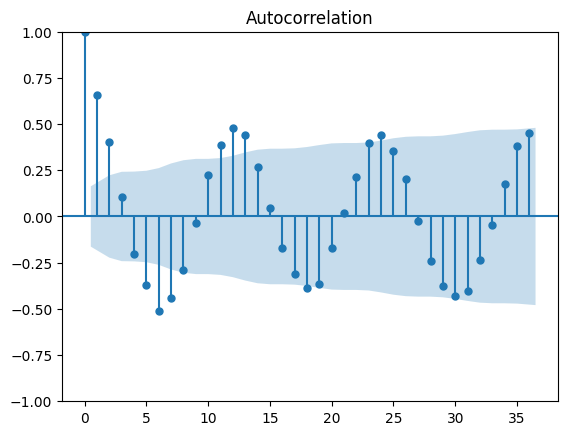

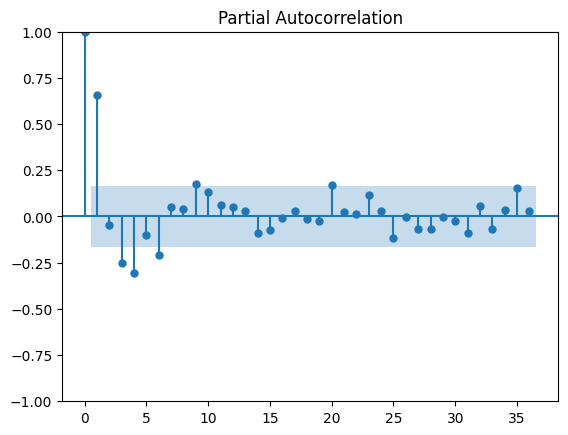

In [ ]:
plot_acf(ts_nat, lags=36)
plt.show()
plot_pacf(ts_nat, lags=36)
plt.show()

Teste de estacionariedade **KPSS**

In [ ]:
stat_nat, p_value_nat, lags_nat, crit_nat = kpss(ts_nat, regression='c')

print("BASE NATAL\n")
print(f"KPSS Statistic: {round(stat_nat, 2)}")
print(f"p-value: {round(p_value_nat, 2)}")
print("Nº de lags: ",round(lags_nat, 2))
print("\nValores críticos:\n")
for chave, valor in crit_nat.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE NATAL

KPSS Statistic: 0.24
p-value: 0.1
Nº de lags:  6

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


<ipython-input-11-d10cf5913ad4>:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_nat, p_value_nat, lags_nat, crit_nat = kpss(ts_nat, regression='c')


-> `KPSS Statistic = 0.24` é menor do que todos os valores críticos.

-> `p-value = 0.1 > 0.05` -> **Rejeitamos H₀**, ou seja, há evidência de que a série é estacionária, não necessitando de diferenciação.

Teste **ADF**

In [ ]:
resultado_nat = adfuller(ts_nat)

print("BASE NATAL\n")
print("ADF Statistic:", resultado_nat[0])
print("p-value:", resultado_nat[1])
print("Nº de lags:", resultado_nat[2])
print("Nº de observações:", resultado_nat[3])
print("Valores críticos:")
for chave, valor in resultado_nat[4].items():
    print(f"   {chave}: {valor}")

BASE NATAL

ADF Statistic: -2.7588854848580824
p-value: 0.06439091245211818
Nº de lags: 9
Nº de observações: 134
Valores críticos:
   1%: -3.480118600110386
   5%: -2.8833618426136196
   10%: -2.578407034974382


-> `ADF Statistic = -2.76` não é menor que os valores críticos de 5% ou 1%, mas é menor que o de 10%..

-> `p-value = 0.064 > 0.05` (a ADF rejeita **H₀** ao nível de 10%, mas não ao nível de 5%, indicando **indício de estacionariedade fraca**)

Podemos aplicar a diferenciação e reaplicar os testes.

<Axes: >

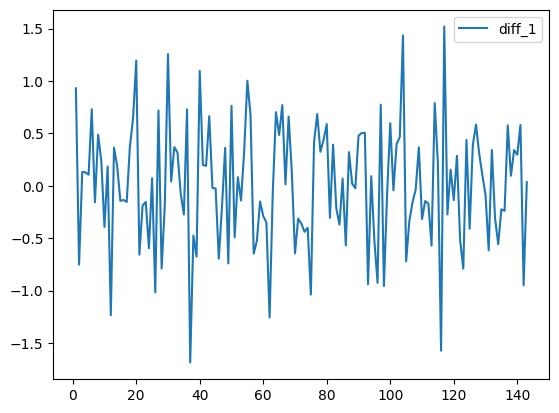

In [ ]:
df_diff_nat = pd.DataFrame()
df_diff_nat['diff_1'] = ts_nat.diff().iloc[1:]

df_diff_nat.plot()

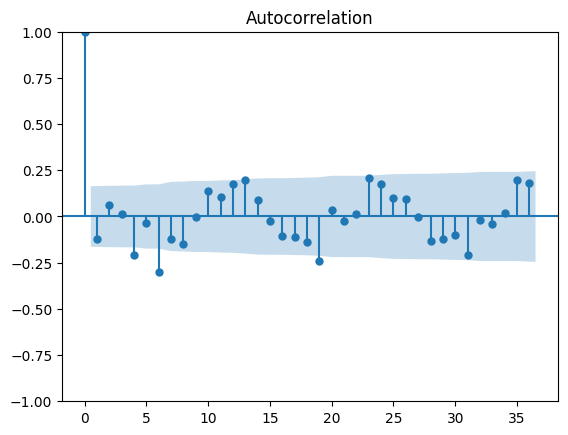

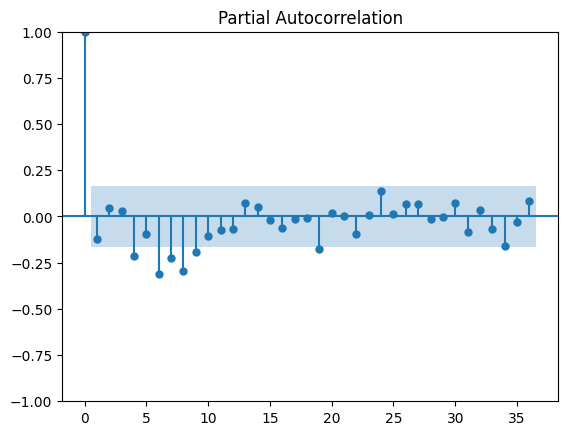

In [ ]:
ts_nat = df_diff_nat['diff_1']
plot_acf(ts_nat, lags=36)
plt.show()
plot_pacf(ts_nat, lags=36)
plt.show()

In [ ]:
stat_nat, p_value_nat, lags_nat, crit_nat = kpss(ts_nat, regression='c')

print("BASE NATAL\n")
print(f"KPSS Statistic: {round(stat_nat, 2)}")
print(f"p-value: {round(p_value_nat, 2)}")
print("Nº de lags: ",round(lags_nat, 2))
print("\nValores críticos:\n")
for chave, valor in crit_nat.items():
    print("{} : {:0.2f}".format(chave, valor))

BASE NATAL

KPSS Statistic: 0.02
p-value: 0.1
Nº de lags:  1

Valores críticos:

10% : 0.35
5% : 0.46
2.5% : 0.57
1% : 0.74


<ipython-input-15-d10cf5913ad4>:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_nat, p_value_nat, lags_nat, crit_nat = kpss(ts_nat, regression='c')


In [ ]:
resultado_nat = adfuller(ts_nat)

print("BASE NATAL\n")
print("ADF Statistic:", resultado_nat[0])
print("p-value:", resultado_nat[1])
print("Nº de lags:", resultado_nat[2])
print("Nº de observações:", resultado_nat[3])
print("Valores críticos:")
for chave, valor in resultado_nat[4].items():
    print(f"   {chave}: {valor}")

BASE NATAL

ADF Statistic: -7.990436240581283
p-value: 2.482854926800773e-12
Nº de lags: 9
Nº de observações: 133
Valores críticos:
   1%: -3.480500383888377
   5%: -2.8835279559405045
   10%: -2.578495716547007


#### **Definição das funções: mutação, fitness, evolução, pipeline de dados, modelos**

##### Funções

In [ ]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.losses import MeanSquaredError
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from scipy.special import gamma
import time

def log_results(base_name: str,
                model_name: str,
                mses: list[float],
                filename: str = "results_log.csv"):
    """
    Recebe:
      - base_name: p.ex. "Recife"
      - model_name: p.ex. "EvoRNN"
      - mses: lista de MSEs (uma por execução)
      - filename: caminho do CSV de log

    Cria/atualiza `filename` adicionando uma linha por execução:
      base,model,run,mse
    """
    # 1) Monta um DataFrame temporário com as novas execuções
    n = len(mses)
    df_new = pd.DataFrame({
        "base":  [base_name]*n,
        "model": [model_name]*n,
        "run":   list(range(1, n+1)),
        "mse":   mses
    })

    # 2) Se o arquivo já existe, abre em modo append
    if os.path.exists(filename):
        df_new.to_csv(filename, mode="a", header=False, index=False)
    else:
        # Caso contrário, cria com cabeçalho
        df_new.to_csv(filename, mode="w", header=True, index=False)

def gerar_dados_temporais(ts):
    """
    Converte uma série temporal real em dados para RNN com lag fixo de 12.

    Parâmetros:
        ts: pd.Series ou np.array contendo a série temporal (ex: df['diff_1'])

    Retorna:
        X: array de shape (n_amostras, 12, 1)
        y: array de shape (n_amostras, 1)
    """
    seq_len = 12
    dados = np.array(ts).flatten()
    n_amostras = len(dados) - seq_len # 143 - 12 = 131 (i) pares X e y. i: 130 -> X[130] = dados[130:142], y[130] = dados[142]

    X, y = [], []
    for i in range(n_amostras):
        X.append(dados[i:i + seq_len])      # 12 valores de entrada - janela deslizante
        y.append(dados[i + seq_len])        # valor seguinte (13º) -> target

    # # adiciona um novo eixo a X e y
    X = np.array(X)[..., np.newaxis]        # shape: (n_amostras, 12, 11~novo eixo)
    y = np.array(y)[..., np.newaxis]        # shape: (n_amostras, 11~novo eixo)

    return X, y

# Normalizador ajustado apenas no treino
def normalizar_serie_parcial(ts_train, ts_val, ts_test):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    ts_train_norm = scaler.fit_transform(ts_train.reshape(-1, 1))
    ts_val_norm = scaler.transform(ts_val.reshape(-1, 1))
    ts_test_norm = scaler.transform(ts_test.reshape(-1, 1))
    return ts_train_norm, ts_val_norm, ts_test_norm, scaler

# Pipeline de dados
def pipeline_dados(ts, proporcao_treino=0.6, proporcao_val=0.2, norm=False):
    seq_len = 12
    dados = np.array(ts).reshape(-1, 1)
    n_total = len(dados) - seq_len

    n_train = int(n_total * proporcao_treino)
    n_val = int(n_total * proporcao_val)
    n_test = n_total - n_train - n_val

    idx_train = n_train + seq_len
    idx_val = idx_train + n_val

    ts_train = dados[:idx_train]
    ts_val = dados[idx_train - seq_len:idx_val]
    ts_test = dados[idx_val - seq_len:]

    if norm:
        ts_train, ts_val, ts_test, scaler = normalizar_serie_parcial(ts_train, ts_val, ts_test)
    else:
        scaler = None  # apenas pra manter compatibilidade

    X_train, y_train = gerar_dados_temporais(ts_train)
    X_val, y_val = gerar_dados_temporais(ts_val)
    X_test, y_test = gerar_dados_temporais(ts_test)

    if norm:
        return X_train, X_val, X_test, y_train, y_val, y_test, scaler
    else:
        return X_train, X_val, X_test, y_train, y_val, y_test

# Modelo base de RNN (IRÁ VARIAR DENTRO DO GRIDSEARCH)
# seq_len: janela de valores; unidades: qtd neurônios
# input_shape=(seq_len, 1): espera entradas com 'seq_len' timesteps e 1 feature por timestep
def criar_rnn(seq_len=12, unidades=12):
    #model = Sequential([
    #    SimpleRNN(unidades, input_shape=(seq_len, 1), activation='tanh'),
    #    Dense(1)

    model = Sequential([
        Input(shape=(seq_len, 1)),
        SimpleRNN(unidades, activation='tanh'),
        Dense(1)
    ])
    return model

def criar_rnn_backprop(seq_len=12, unidades=20, lr=0.001):
    """
    Cria e compila uma rede Elman (SimpleRNN) para treino com backpropagation.

    Parâmetros:
    - seq_len: número de passos de tempo na entrada
    - unidades: número de unidades da camada recorrente
    - lr: taxa de aprendizado

    Retorna:
    - modelo Keras compilado
    """
    model = Sequential([
        SimpleRNN(unidades, input_shape=(seq_len, 1), activation='tanh'),
        Dense(1)

    ])

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Definir pesos (atribui pesos manuais ao modelo Keras)
def set_pesos(model, vetor_pesos): # model: instância do modelo Keras; vetor_pesos: vetor linear de floats (genes de um indivíduo da população)
    pesos = model.get_weights()
    shapes = [w.shape for w in pesos] # extrai os shapes de cada array de pesos (ex: [kernel, recurrent_kernel, bias, dense_kernel, dense_bias])
    novos_pesos = []
    idx = 0
    for s in shapes:
        size = np.prod(s)          # produto da dimensão de 's' (calcula qtd de valores necessários para preencher esse peso)
        novos_pesos.append(vetor_pesos[idx:idx+size].reshape(s)) # Extrai a fatia correta do 'vetor_pesos' e a redimensiona para o shape original 's'
        idx += size                # Atualiza o índice para a próxima fatia
    model.set_weights(novos_pesos) # Atribui os pesos reconstruídos ao modelo

# Fitness: erro da RNN com pesos fornecidos

# ind: vetor de pesos (indivíduo da 'pop', se torna 'vetor_pesos' na chamada de 'set_pesos()')
# X: dados de entrada da rede
# y: saídas esperadas
def fitness_rnn(ind, X, y, modelo_base):
    modelo = tf.keras.models.clone_model(modelo_base) # Cria uma cópia estrutural do modelo
    modelo.build(input_shape=(None, X.shape[1], 1))   # "Compila" a estrutura da rede para que ela possa receber pesos e aceitar entradas. X.shape[1] será igual a 'seq_len'
    set_pesos(modelo, ind)                            # Aplica os pesos da solução evoluída ao modelo copiado, garantindo que a RNN tenha comportamento definido por 'ind'
    pred = modelo.predict(X, verbose=0)               # predict do modelo com pesos evoluídos sobre os dados 'X'
    return MeanSquaredError()(y, pred).numpy()        # retorna o MSE como fitness

# Operador de mutação
def mut_gaussian(x, sigma=0.1):
    return x + np.random.normal(0, sigma, size=x.shape)

def mutacao_adaptativa(ind, gen, n_gen, sigma_inicial=0.5, sigma_min=0.01):
    """
    Aplica mutação gaussiana com sigma decaindo ao longo das gerações.
    """
    sigma = sigma_min + (sigma_inicial - sigma_min) * ((n_gen - gen) / n_gen)
    return ind + np.random.normal(0, sigma, size=ind.shape)

def torneio(pop, fitness, k=3):
    idxs = np.random.choice(len(pop), k, replace=False)
    vencedor_idx = idxs[np.argmin(fitness[idxs])]
    return pop[vencedor_idx]

def roleta_inversa(pop, fitness, temperatura=1.0):
    """
    Seleção por roleta inversa com escalonamento exponencial.

    Parâmetros:
        pop: população de indivíduos
        fitness: array com os valores de fitness (quanto menor, melhor)
        temperatura: parâmetro de suavização para o escalonamento (T > 0)

    Retorna:
        Um indivíduo selecionado por roleta inversa com base nos fitness escalonados.
    """
    fit_inv = np.exp(-fitness / temperatura)  # quanto menor o fitness, maior o valor após exp
    probs = fit_inv / np.sum(fit_inv)         # normaliza para formar uma distribuição de probabilidade
    idx = np.random.choice(len(pop), p=probs) # seleção via distribuição de probabilidade
    return pop[idx]

# Algoritmo de programação evolutiva (EP)
def evoluir(fitness_func, mutacao_func, X_train, y_train, X_val, y_val, X_test, y_test, modelo_base,
            n_execucoes=10, n_gen=100, tamanho_pop=30, n_genes=100, seed_base=1):
    historico_exec_treino = []
    historico_exec_val = []
    test_mses = [] # salva as 'n_execucoes' predições no teste

    melhor_global = None # ESSAS DUAS LINHAS ENTRAM DENTRO DO LOOP DE EXECUÇÃO, LOGO ABAIXO DAS LISTAS DE HISTORICO
    melhor_fitness_global = np.inf

    for execucao in range(n_execucoes):
        melhor_exec = None # armazenam o melhor da execução para predict no teste
        melhor_fitness_exec = np.inf

        np.random.seed(seed_base + execucao) # para reprodutibilidade
        pop = np.random.uniform(-1, 1, size=(tamanho_pop, n_genes)) # inicialização aleatória dos pesos
        historico_treino = []
        historico_val = []

        for gen in range(n_gen):
            # Calcula e armazena o melhor individuo no conjunto de treino
            fitness = np.array([fitness_func(ind, X_train, y_train, modelo_base) for ind in pop])
            idx_melhor = np.argmin(fitness)
            melhor = pop[idx_melhor]
            historico_treino.append(fitness[idx_melhor])

            # Avaliação o 'melhor' no conjunto de validação
            fitness_val = fitness_func(melhor, X_val, y_val, modelo_base)
            historico_val.append(fitness_val)

            # armazena os pesos (genes) do melhor indivíduo da 'n_execucao'
            if fitness_val < melhor_fitness_exec:
              melhor_exec = melhor.copy()
              melhor_fitness_exec = fitness_val

            # armazena os pesos do melhor indivíduo geral para todo 'n_execucao' e 'n_gen'
            if fitness_val < melhor_fitness_global:
              melhor_global = melhor.copy()
              melhor_fitness_global = fitness_val

            # Muta o melhor no conjunto de treino para gerar a próxima população (elitista deterministica)
            pop = np.array([mutacao_func(melhor.copy()) for _ in range(tamanho_pop)])

        # APÓS TODAS AS GERAÇÕES, DE POSSE DO MELHOR INDIVIDUO DA EXECUÇÃO, FAZER O PREDICT NO TESTE E ARMAZENAR AQUI
        fitness_test = fitness_func(melhor_exec, X_test, y_test, modelo_base)
        test_mses.append(fitness_test)

        historico_exec_treino.append(historico_treino)
        historico_exec_val.append(historico_val)

    # ENTRA DENTRO DO LOOP DA EXECUÇÃO????
    best_model = melhor_global # salvando o modelo da última geração
    best_fitness = melhor_fitness_global

    # Métricas de treino
    historico_exec_treino = np.array(historico_exec_treino)
    historico_medio_treino = np.mean(historico_exec_treino, axis=0)
    desvio_padrao_treino = np.std(historico_exec_treino, axis=0)
    media_final_treino = np.mean(historico_exec_treino[:, -1])

    # Métricas de validação
    historico_exec_val = np.array(historico_exec_val)
    historico_medio_val = np.mean(historico_exec_val, axis=0)
    desvio_padrao_val = np.std(historico_exec_val, axis=0)
    media_final_val = np.mean(historico_exec_val[:, -1])

    return (historico_medio_treino, desvio_padrao_treino, media_final_treino,
            historico_medio_val, desvio_padrao_val, media_final_val, best_model, best_fitness, test_mses)

##### Experimentos - Base Recife

###### EvoRNN

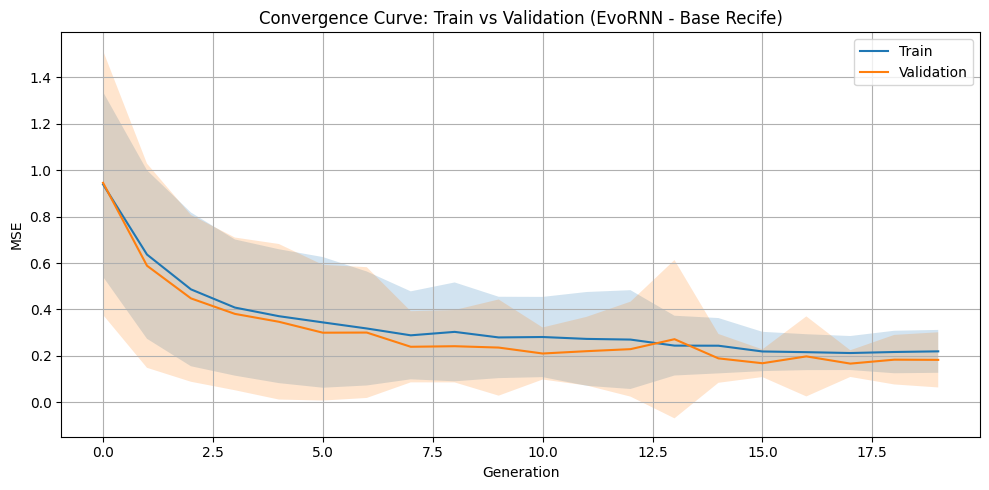


Evornn training time (base Recife) : 203 minuts and 13 seconds.


In [ ]:
'''Para normalizar a série passada para a função 'pipeline_dados', setar 'norm=True' e adicionar 'scaler' após 'y'_test
   Em caso contrário, setar 'norm=False' e remover 'scaler' após 'y_test' '''

# Pipeline completo dos dados
X_train_rec, X_val_rec, X_test_rec, y_train_rec, y_val_rec, y_test_rec, scaler_rec = pipeline_dados(ts_rec, norm=True)

# Cria o modelo base com entrada de 12 lags
modelo_base = criar_rnn(seq_len=12, unidades=20)
modelo_base.build(input_shape=(None, 12, 1))  # define o shape de entrada para uso em build()

# Dimensiona quantidade de pesos necessários a serem evoluídos para o modelo
n_genes = sum(np.prod(w.shape) for w in modelo_base.get_weights())

start_time_evornn = time.time()

resultados_rec = evoluir(
    fitness_func=fitness_rnn,
    mutacao_func=mut_gaussian,
    X_train=X_train_rec,
    y_train=y_train_rec,
    X_val=X_val_rec,
    y_val=y_val_rec,
    X_test=X_test_rec,
    y_test=y_test_rec,
    modelo_base=modelo_base,
    n_execucoes=30,
    n_gen=20,
    tamanho_pop=30,
    n_genes=n_genes
)

(h_treino, std_treino, final_treino,
 h_val, std_val, final_val, best_model_evornn_rec, best_fitness_evornn_rec, test_mses_evornn_rec) = resultados_rec

log_results("Recife", "EvoRNN", test_mses_evornn_rec) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (EvoRNN - Base Recife)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time_evornn = time.time()

elapsed_time_evornn = end_time_evornn - start_time_evornn
minutes_evornn = int(elapsed_time_evornn // 60)
seconds_evornn = int(elapsed_time_evornn % 60)

print(f"\nEvornn training time (base Recife) : {minutes_evornn} minuts and {seconds_evornn} seconds.")

In [ ]:
print('EvoRNN - Base Recife:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.2} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.3}")
print(f"\nBest MSE validation: {best_fitness_evornn_rec :.4}")

EvoRNN - Base Recife:

MSE final training: 0.2192 +- 0.092 
MSE final validation: 0.1824 +- 0.119

Best MSE validation: 0.1033


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


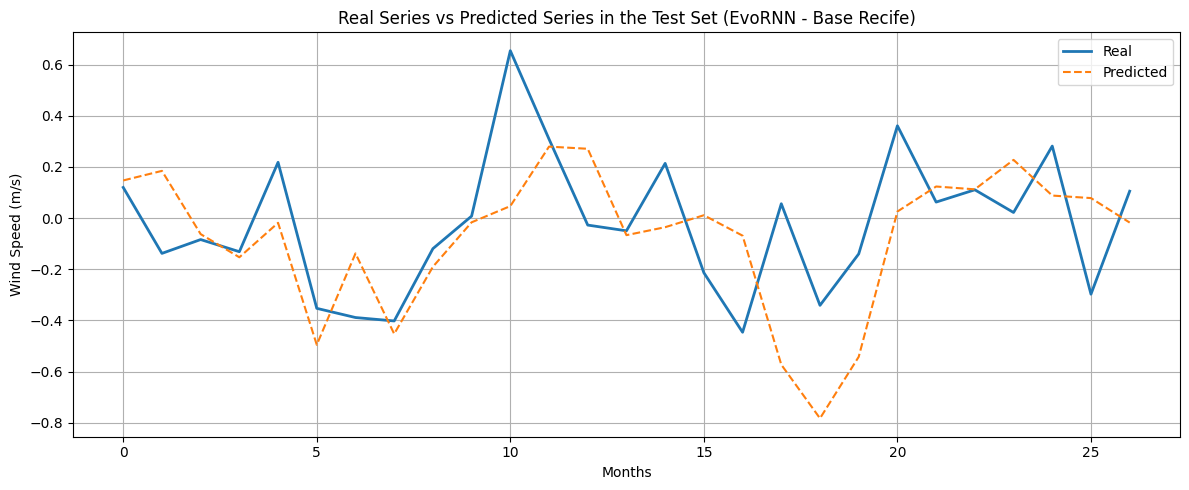

In [ ]:
# Criar modelo com mesma arquitetura
evornn_rec = tf.keras.models.clone_model(modelo_base)
evornn_rec.build(input_shape=(None, X_test_rec.shape[1], 1))

# Aplicar os melhores pesos evoluídos
set_pesos(evornn_rec, best_model_evornn_rec)

# Prever a série de teste
y_pred_evornn_rec = evornn_rec.predict(X_test_rec)

# Inverter a normalização para 'y_pred' e 'y_test'
y_pred_evornn_real_rec = scaler_rec.inverse_transform(y_pred_evornn_rec)
y_test_real_rec = scaler_rec.inverse_transform(y_test_rec)

plt.figure(figsize=(12, 5))
plt.plot(y_test_real_rec.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_evornn_real_rec.flatten(), label="Predicted", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (EvoRNN - Base Recife)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
mse_test_evornn_rec  = mean_squared_error(y_test_real_rec, y_pred_evornn_real_rec)
print(f"MSE test (Elman Network + EP - Base Recife): {mse_test_evornn_rec :.4f}")

MSE test (Elman Network + EP - Base Recife): 0.0767


In [ ]:
# Salva o array
np.save('y_pred_evornn_real_rec.npy', y_pred_evornn_real_rec)


In [ ]:
# Carrega o array de volta para uma nova variável
loaded_data = np.load('y_pred_evornn_real_rec.npy')

###### Elman Network (otimização via gradiente)

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

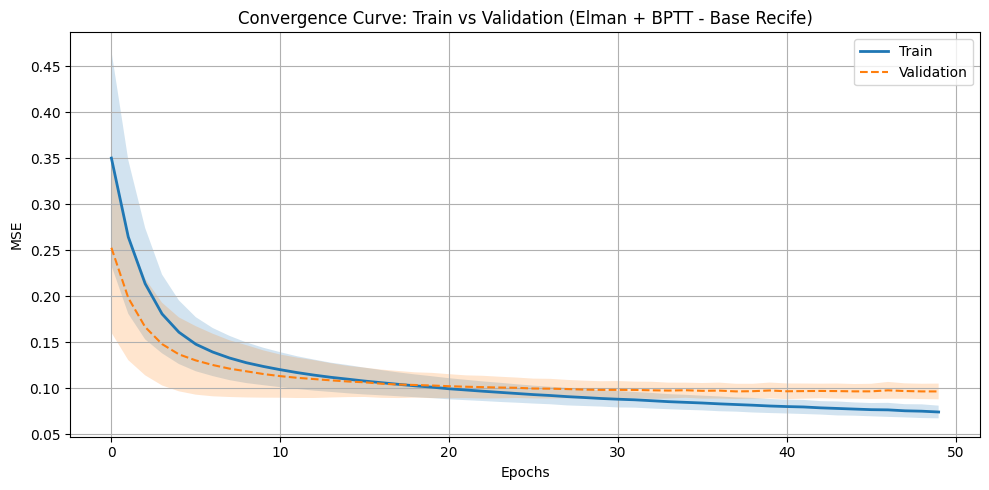

In [ ]:
n_execucoes = 30
n_epocas = 50
batch_size = 16
seed_base = 1

# Matrizes para armazenar o histórico de perda por execução
historico_treino = np.zeros((n_execucoes, n_epocas))
historico_val = np.zeros((n_execucoes, n_epocas))
preds_bptt_rec = []
test_mses_bptt_rec = []

historico_treino = np.zeros((n_execucoes, n_epocas))
historico_val = np.zeros((n_execucoes, n_epocas))
preds = []
test_mses = []

#X_train_rec, X_val_rec, X_test_rec, y_train_rec, y_val_rec, y_test_rec, scaler_rec = pipeline_dados(ts_rec, norm=True)

for i in range(n_execucoes):
    #print(f"Execução {i+1}/{n_execucoes}")

    np.random.seed(seed_base + i) # para reprodutibilidade

    modelo_rnn_rec = criar_rnn_backprop(seq_len=12, unidades=20, lr=0.001)

    history_rnn_rec = modelo_rnn_rec.fit(
        X_train_rec, y_train_rec,
        validation_data=(X_val_rec, y_val_rec),
        epochs=n_epocas,
        batch_size=batch_size,
        verbose=0
    )

    historico_treino[i, :] = history_rnn_rec.history['loss']
    historico_val[i, :] = history_rnn_rec.history['val_loss']

    # predict para cada 'n_execucoes'
    y_pred_bptt_rec = modelo_rnn_rec.predict(X_test_rec)
    preds_bptt_rec.append(y_pred_bptt_rec)

    # MSEs para cada 'n_execucoes'
    mse_test_bptt_rec = MeanSquaredError()(y_test_rec, y_pred_bptt_rec).numpy()
    test_mses_bptt_rec.append(mse_test_bptt_rec)

log_results("Recife", "Elman_bptt", test_mses_bptt_rec) # salva os MSEs das 30 execuções

# Cálculo da média e do desvio padrão durante treinamento
mse_medio_treino = np.mean(historico_treino, axis=0)
mse_std_treino = np.std(historico_treino, axis=0)

mse_medio_val = np.mean(historico_val, axis=0)
mse_std_val = np.std(historico_val, axis=0)

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train", linewidth=2)
plt.fill_between(range(n_epocas), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation", linestyle='--')
plt.fill_between(range(n_epocas), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (Elman + BPTT - Base Recife)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print('Elman + BPTT - Base Recife:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")

Elman + BPTT - Base Recife:

MSE final training : 0.074 +- 0.0069 
MSE final validation: 0.0964 +- 0.0085


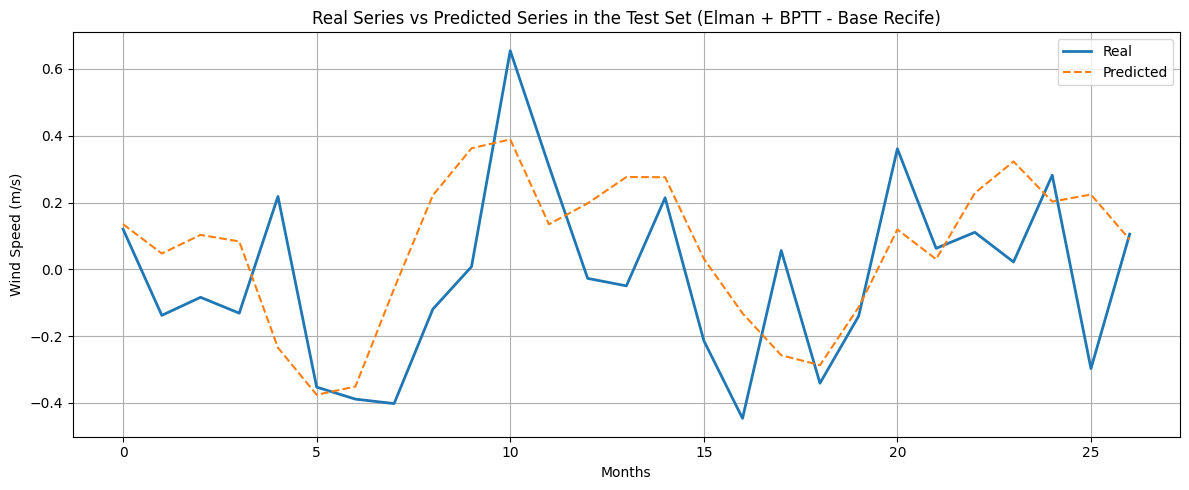

In [ ]:
# média das predições das 'n_execucoes'
y_mean_preds_rec = np.mean(preds_bptt_rec, axis=0)

# Inversão da normalização
y_pred_bptt_real_rec = scaler_rec.inverse_transform(y_mean_preds_rec)
y_test_real_rec = scaler_rec.inverse_transform(y_test_rec)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_rec.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_bptt_real_rec.flatten(), label="Predicted", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (Elman + BPTT - Base Recife)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_teste_bptt_rec = mean_squared_error(y_test_real_rec, y_pred_bptt_real_rec)

print('Elman Network + BPTT - Base Recife')
print(f"\nMSE test: {mse_teste_bptt_rec:.4f}")

Elman Network + BPTT - Base Recife

MSE test: 0.0610


In [ ]:
# Save the array to a file named 'y_pred_data.npy'
np.save('y_pred_bptt_real_rec.npy', y_pred_bptt_real_rec)

In [ ]:
# Carrega o array de volta para uma nova variável
loaded_data = np.load('y_pred_evornn_real_rec.npy')

###### GA-MLP (Sibarama Panigrahi)

In [ ]:
# ———————————————————————————————————————————————————————————————————————
# 1) Funções auxiliares para o MLP 12–2–1
# ———————————————————————————————————————————————————————————————————————

def mlp_predict(individual, x):
    """
    Dada uma janela x (shape=(12,)), e o vetor plano de pesos `individual`
    (length = 2*(12+1) + 1*(2+1) = 29), devolve a predição escalar y.
    Arquitetura: 12 inputs → 2 hidden tanh → 1 saída linear.
    """
    # Decodifica o vetor de genes em W1, b1, W2, b2
    #  1) entrada→oculta
    offset = 0
    W1 = individual[offset:offset+2*12].reshape(2,12); offset += 2*12
    b1 = individual[offset:offset+2];          offset += 2
    #  2) oculta→saída
    W2 = individual[offset:offset+2*1].reshape(1,2); offset += 2*1
    b2 = individual[offset]                      # offset += 1

    # forwarding
    h = np.tanh(W1.dot(x) + b1)      # shape (2,)
    y = W2.dot(h) + b2               # shape (1,)

    return y.flatten()

def fitness_mlp(individual, X, y):
    """
    Fitness = RMSE no conjunto (X,y). Aqui usamos MSE para seleção (menor melhor).
      X: shape (n_samples, 12, 1)
      y: shape (n_samples, 1)
    """
    preds = []
    for i in range(X.shape[0]):
        x = X[i,:,0]               # vetor de 12 valores
        preds.append( mlp_predict(individual, x) )
    preds = np.array(preds).reshape(-1)
    true  = y.reshape(-1)
    return mean_squared_error(true, preds)   # RMSE (TROCAR PARA MSE, apenas apagar 0.5)

# ———————————————————————————————————————————————————————————————————————
# 2) Operadores genéticos
# ———————————————————————————————————————————————————————————————————————

def one_point_crossover(p1, p2):
    size = len(p1)
    pt = np.random.randint(1, size)      # ponto de corte entre 1 e size-1
    child = np.empty_like(p1)
    child[:pt] = p1[:pt]
    child[pt:] = p2[pt:]
    return child

# esse operador é o análogo real-codificado do bit flip com probabilidade 0.3 do GA original
# com adição de ruído gaussiano nos genes a serem mutados
def mutation(p, mut_prob=0.3, sigma=0.1):
    """
    Mutação por ruído gaussiano: para cada gene, com prob=mut_prob,
    adiciona-se N(0, sigma²).
    """
    mask = np.random.rand(len(p)) < mut_prob # marca cada gene que vai sofrer mutação
    noise = np.random.normal(0, sigma, size=len(p))
    child = p.copy()
    child[mask] += noise[mask] # adiciona ruído gaussiano apenas nos genes marcados
    return child

# ———————————————————————————————————————————————————————————————————————
# 3) O GA principal
# ———————————————————————————————————————————————————————————————————————

def ga_train_mlp(X_train, y_train, X_val, y_val, X_test, y_test, input_size=12, hidden_size=2, output_size=1,
    pop_size=50, generations=10, crossover_prob=0.7, mutation_prob=0.3, sigma=0.1, n_execucao=10, seed_base=1):

    historico_exec_treino = []
    historico_exec_val = []
    test_mses = []

    best_global = None
    best_fitness_global = np.inf

    # Armazena o melhor MSE da validação e o indivíduo
    #best_val_mse = np.inf
    #best_ind   = None

    n_genes = hidden_size*(input_size+1) + output_size*(hidden_size+1)

    for execucao in range(n_execucao):
        np.random.seed(seed_base + execucao) # para reprodutibilidade

        # 3.1) inicialização da população
        pop = np.random.uniform(-1, 1, (pop_size, n_genes))

        historico_treino = []
        historico_val = []

        # Armazena o melhor MSE da validação e o indivíduo da execução
        # Reseta ao inicio de cada 'n_execucao'
        best_val_mse = np.inf
        best_ind   = None

        # Guarda cópia para possível revert
        prev_pop = pop.copy()

        gen = 0
        while gen < generations:
            # ——————————————————————————————————————————
            # 3.a–3.b) Para cada cromossomo: mutation, crossover, seleção
            # ——————————————————————————————————————————
            new_pop = np.empty_like(pop)
            for i in range(pop_size):
                parent = pop[i]
                # escolhe dois outros pais aleatórios
                a, b = np.random.choice(pop_size, 2, replace=False)
                p1, p2 = pop[a], pop[b]

                # mutation + crossover → trial
                trial = parent.copy()
                if np.random.rand() < crossover_prob:
                    trial = one_point_crossover(p1, p2)
                trial = mutation(trial, mut_prob=mutation_prob, sigma=sigma)

                # 3.d) avaliação de fitness
                fit_parent = fitness_mlp(parent, X_train, y_train) # sem mutação/crossover
                fit_trial  = fitness_mlp(trial,  X_train, y_train) # pode ter sofrido mutação/crossover ou não
                # 3.e) seleciona trial se tiver fitness melhor que parent
                new_pop[i] = trial if fit_trial < fit_parent else parent

            # ——————————————————————————————————————————
            # 3.f) avalia melhor da nova população em VALIDAÇÃO
            # ——————————————————————————————————————————
            # encontra MSE de cada indivíduo no treino
            train_mses = np.array([fitness_mlp(ind, X_train, y_train) for ind in new_pop])
            idx_min_train   = np.argmin(train_mses) # pega o indice de menor (melhor) fitness no treino
            cur_best_train  = train_mses[idx_min_train] # localiza o melhor fitness no treino

            # encontra MSE de cada indivíduo na validação
            val_mses = np.array([fitness_mlp(ind, X_val, y_val) for ind in new_pop])
            idx_min   = np.argmin(val_mses) # pega o indice de menor (melhor) fitness
            cur_best  = val_mses[idx_min] # localiza o melhor fitness

            if cur_best <= best_val_mse:
                # aceita geração e atualiza “melhor”
                best_val_mse = cur_best
                best_ind = new_pop[idx_min].copy()
                pop = new_pop # nova população atualizada
                prev_pop = pop.copy()
                gen += 1

                # Só atualiza o histórico se a geração for aceita
                historico_treino.append(cur_best_train)
                historico_val.append(cur_best)
                #print(f" Geração {gen:3d} → Val_RMSE improved to {best_val_mse:.4f}")
            else:
                # rejeita e “volta” à população anterior (passo 3.b)
                pop = prev_pop.copy()
                #print(f" Geração {gen+1:3d} → Val_RMSE worsened ({cur_best:.4f}), regenerating…

        # FAZER AQUI O PREDICT NO TESTE COM O 'best_ind' DA EXECUÇÃO
        # Deve ser feito antes do 'if' abaixo, pois 'best_val_mse' (e, portanto o 'best_ind') da 'n_execucao[t]'
        # pode não superar o 'best_val_mse' da 'n_execucao[t-1]' (ou seja, 'best_fitness_global'). Assim
        # garantimos que o predict no teste será feito com o 'best_ind' da execução atual.
        fitness_test = fitness_mlp(best_ind, X_test, y_test)
        test_mses.append(fitness_test)

        # armazena os genes do melhor indivíduo geral para todo 'n_execucao' e 'n_gen'
        if best_val_mse < best_fitness_global:
          best_model_global = best_ind.copy()
          best_fitness_global = best_val_mse

        # armazena os históricos de treino e validação de cada 'n_execucao'
        historico_exec_treino.append(historico_treino)
        historico_exec_val.append(historico_val)

    # Métricas de treino
    historico_exec_treino = np.array(historico_exec_treino)
    historico_medio_treino = np.mean(historico_exec_treino, axis=0)
    desvio_padrao_treino = np.std(historico_exec_treino, axis=0)
    media_final_treino = np.mean(historico_exec_treino[:, -1])

    # Métricas de validação
    historico_exec_val = np.array(historico_exec_val)
    historico_medio_val = np.mean(historico_exec_val, axis=0)
    desvio_padrao_val = np.std(historico_exec_val, axis=0)
    media_final_val = np.mean(historico_exec_val[:, -1])

    return (historico_medio_treino, desvio_padrao_treino, media_final_treino,
           historico_medio_val, desvio_padrao_val, media_final_val, best_model_global, best_fitness_global, test_mses)

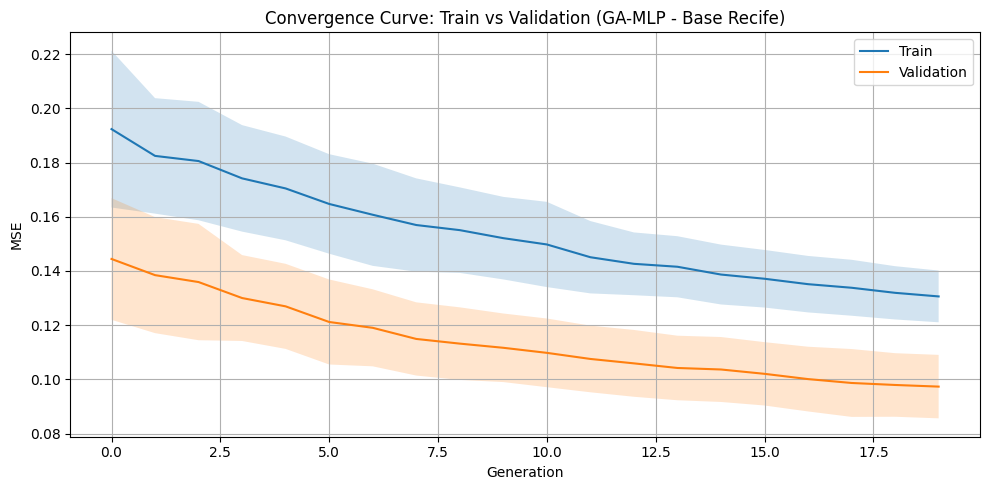


GA-MLP training time (base Recife) : 3 minuts and 11 seconds.


In [ ]:
# Pipeline completo dos dados
X_train_rec, X_val_rec, X_test_rec, y_train_rec, y_val_rec, y_test_rec, scaler_rec = pipeline_dados(ts_rec, norm=True)

start_time_evornn = time.time()

resultados_ga_mlp_rec = ga_train_mlp(
    X_train=X_train_rec,
    y_train=y_train_rec,
    X_val=X_val_rec,
    y_val=y_val_rec,
    X_test=X_test_rec,
    y_test=y_test_rec,
    pop_size=30,
    generations=20,
    n_execucao=30
)

(h_treino, std_treino, final_treino, h_val, std_val, final_val, best_model_ga_mlp_rec,
 best_fitness_ga_mlp_rec, test_mses_ga_mlp_rec) = resultados_ga_mlp_rec

log_results("Recife", "GA_MLP", test_mses_ga_mlp_rec) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (GA-MLP - Base Recife)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time_evornn = time.time()

elapsed_time_evornn = end_time_evornn - start_time_evornn
minutes_evornn = int(elapsed_time_evornn // 60)
seconds_evornn = int(elapsed_time_evornn % 60)

print(f"\nGA-MLP training time (base Recife) : {minutes_evornn} minuts and {seconds_evornn} seconds.")

In [ ]:
print('GA-MLP - Base Recife:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.2} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.3}")
print(f"\nBest MSE validation: {best_fitness_ga_mlp_rec:.4}")

GA-MLP - Base Recife:

MSE final training: 0.1306 +- 0.0095 
MSE final validation: 0.09733 +- 0.0117

Best MSE validation: 0.0735


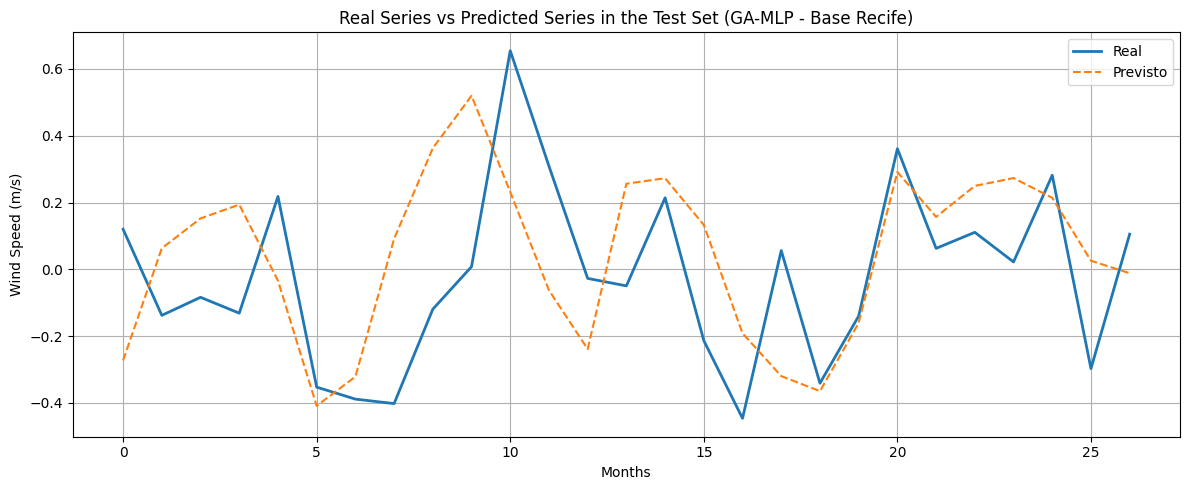

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_rec.shape[0]):
    x = X_test_rec[i,:,0]               # vetor de 12 valores
    preds.append(mlp_predict(best_model_ga_mlp_rec, x))
y_pred_ga_mlp_rec = np.array(preds).reshape(-1)

# desnormalizar as predições e o target
y_pred_ga_mlp_real_rec = scaler_rec.inverse_transform(y_pred_ga_mlp_rec.reshape(-1, 1))
y_test_real_rec = scaler_rec.inverse_transform(y_test_rec.reshape(-1, 1))

# plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_rec.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_mlp_real_rec.flatten(), label="Previsto", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-MLP - Base Recife)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_ga_mlp_rec  = mean_squared_error(y_test_real_rec, y_pred_ga_mlp_real_rec)
print(f"MSE test (GA-ANN - Base Recife): {mse_test_ga_mlp_rec :.4f}")

MSE test (GA-ANN - Base Recife): 0.0803


In [ ]:
# salva o array
np.save('y_pred_ga_mlp_real_rec.npy', y_pred_ga_mlp_real_rec)

###### GA-Elman (Qian Wu)

In [ ]:
# ———————————————————————————————————————————————————————————————————————
# 1) Funções auxiliares para o MLP 12–10–1
# ———————————————————————————————————————————————————————————————————————

def elman_predict(individual, x):
    """
    Dada uma janela x (shape=(12,)), e o vetor plano de pesos `individual`
    (length = 10*(12+1) + 1*(10+1) = 141), devolve a predição escalar y.
    Arquitetura: 12 inputs → 2 hidden tanh → 1 saída linear.

    """
    # Decodifica o vetor de genes em W1, b1, W2, b2
    #  1) entrada→oculta - W1: (hidden_size, input_size)
    offset = 0
    W1 = individual[offset:offset+10*12].reshape(10,12)
    offset += 10*12
    b1 = individual[offset:offset+10]  # bias da entrada - b1: (hidden_size,)
    offset += 10
    #  2) oculta→saída - W2: (output_size, hidden_size
    W2 = individual[offset:offset+1*10].reshape(1,10)
    offset += 1*10
    b2 = individual[offset]           # bias da camada escondida - b2: (output_size,)

    # forward pass
    h = np.tanh(W1.dot(x) + b1)      # h.shape == (10,)
    y = W2.dot(h) + b2               # y.shape == (1,)

    return y.flatten() # array de tamanho 1

def fitness_elman(individual, X, y):
    """
    Fitness = RMSE no conjunto (X,y). Aqui usamos MSE para seleção (menor melhor).
      X: shape (n_samples, 12, 1)
      y: shape (n_samples, 1)
    """
    preds = []
    for i in range(X.shape[0]):
        x = X[i,:,0]               # vetor de 12 valores
        preds.append( elman_predict(individual, x) )
    preds = np.array(preds).reshape(-1)
    true  = y.reshape(-1)
    return mean_squared_error(true, preds)

# ———————————————————————————————————————————————————————————————————————
# 2) Operadores genéticos
# ———————————————————————————————————————————————————————————————————————

def roulette_select(fitnesses):
    """Roleta inversa: indivíduos com menor MSE têm maior chance."""
    inv = 1.0/(fitnesses + 1e-8)
    probs = inv/np.sum(inv)
    return np.random.choice(len(fitnesses), p=probs)

def one_point_crossover(p1, p2):
    size = len(p1)
    pt = np.random.randint(1, size)      # ponto de corte entre 1 e size-1
    child = np.empty_like(p1)
    child[:pt] = p1[:pt]
    child[pt:] = p2[pt:]
    return child

# esse operador é o análogo real-codificado do bit flip com probabilidade 0.3 do GA original
# com adição de ruído gaussiano nos genes a serem mutados
def mutation(p, mut_prob=0.3, sigma=0.1):
    """
    Mutação por ruído gaussiano: para cada gene, com prob=mut_prob,
    adiciona-se N(0, sigma²).
    """
    mask = np.random.rand(len(p)) < mut_prob # marca cada gene que vai sofrer mutação
    noise = np.random.normal(0, sigma, size=len(p))
    child = p.copy()
    child[mask] += noise[mask] # adiciona ruído gaussiano apenas nos genes marcados
    return child

# ———————————————————————————————————————————————————————————————————————
# 3) O GA Elman principal
# ———————————————————————————————————————————————————————————————————————

def ga_train_elman(X_train, y_train, X_val, y_val, X_test, y_test, input_size=12, hidden_size=10, output_size=1,
    pop_size=10, generations=20, crossover_prob=0.6, mutation_prob=0.2, sigma=0.1, n_execucao=10, n_epocas=50, batch_size=16, seed_base=1):

    #historico_treino = np.zeros((n_execucao, n_epocas))
    #historico_val = np.zeros((n_execucao, n_epocas))
    #historico_treino = []
    #historico_val = []
    historico_exec_treino = []
    historico_exec_val = []
    preds = []
    test_mses = []

    best_model_global = None
    best_fitness_global = np.inf

    # Armazena o melhor MSE da validação e o indivíduo
    best_val_mse = np.inf
    best_ind   = None

    n_genes = hidden_size*(input_size+1) + output_size*(hidden_size+1)

    for execucao in range(n_execucao):
        np.random.seed(seed_base + execucao) # para reprodutibilidade
        # inicialização da população
        pop = np.random.uniform(-1, 1, (pop_size, n_genes))

        historico_treino = []
        historico_val = []

        # Armazena o melhor MSE da validação e o indivíduo da execução
        # Reseta ao inicio de cada 'n_execucao'
        best_val_mse = np.inf
        best_ind   = None

        gen = 0
        while gen < generations:
            # ——————————————————————————————————————————
            # 1) Avalia o fitness de cada indivíduo na validação
            # ——————————————————————————————————————————

            # O algoritmo não detalha se a avaliação do fitness dos individuos que vai guiar
            # o processo evolutivo é no treino ou na validação.
            train_mses = np.array([fitness_elman(ind, X_train, y_train) for ind in pop])

            new_pop = np.empty_like(pop)
            for i in range(pop_size):
                # seleciona dois outros por roleta
                a = roulette_select(train_mses)
                b = roulette_select(train_mses)

                p1, p2 = pop[a], pop[b]

                # crossover
                child = one_point_crossover(p1, p2) if np.random.rand() < crossover_prob else p1.copy()
                # mutação
                child = mutation(child, mut_prob=mutation_prob, sigma=sigma)

                # adiciona o indivíduo na nova população (pode ter sofrido mutado/crossover ou não)
                new_pop[i] = child

            # copia previamente a nova população para calcular fitness em 'pop' no inicio
            # de uma nova geração
            pop = new_pop.copy()

            # ——————————————————————————————————————————
            # avalia melhor da nova população em validação e treino
            # ——————————————————————————————————————————
            # encontra MSE de cada indivíduo no treino
            #best_train_mse = np.min(train_mses) # obtem o melhor mse da geração
            #historico_treino.append(best_train_mse) # adiciona o melhor fitness da geração no treino ao histórico

            # encontra MSE de cada indivíduo na validação
            val_mses = np.array([fitness_elman(ind, X_val, y_val) for ind in new_pop])
            idx_min   = np.argmin(val_mses) # pega o indice de menor (melhor) fitness
            best_ind = new_pop[idx_min].copy() # pega o melhor individuo
            best_val_mse  = val_mses[idx_min] # localiza o melhor fitness
            #historico_val.append(best_val_mse) # adiciona o melhor fitness da geração na validação ao histórico

            gen += 1

        # Treinamento da Elman Network
        # ——————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
        # salvamos o melhor indivíduo da 'n_execucao' para serem utilizados como pesos iniciais da Elman Network
        modelo = criar_rnn_backprop(seq_len=12, unidades=10, lr=0.01)
        modelo.build(input_shape=(None, X_train_rec.shape[1], 1))
        set_pesos(modelo, best_ind) # o melhor indivíduo da 'n_execucao' na validação é implementado como pesos da Elman Network

        history = modelo.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=n_epocas,
            batch_size=batch_size,
            verbose=0
        )

        #historico_treino[i, :] = history.history['loss']
        #historico_val[i, :] = history.history['val_loss']
        historico_exec_treino.append(history.history['loss'])
        historico_exec_val.append(history.history['val_loss'])

        # predict para cada 'n_execucao'
        y_pred = modelo.predict(X_test, verbose=0)
        preds.append(y_pred) # para plots futuros

        # MSEs para cada 'n_execucao'
        mse_test = MeanSquaredError()(y_test, y_pred).numpy()
        test_mses.append(mse_test)

        # ——————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————

        # armazena os genes do melhor indivíduo geral para todo 'n_execucao' e 'n_gen'
        if best_val_mse < best_fitness_global:
          best_model_global = best_ind.copy()
          best_fitness_global = best_val_mse

    historico_exec_treino = np.array(historico_exec_treino)
    historico_exec_val = np.array(historico_exec_val)

    # Cálculo da média e do desvio padrão
    mse_medio_treino = np.mean(historico_exec_treino, axis=0)
    mse_std_treino = np.std(historico_exec_treino, axis=0)

    mse_medio_val = np.mean(historico_exec_val, axis=0)
    mse_std_val = np.std(historico_exec_val, axis=0)

    return (mse_medio_treino, mse_std_treino, mse_medio_val, mse_std_val, best_model_global, best_fitness_global, test_mses)

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not p

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not p

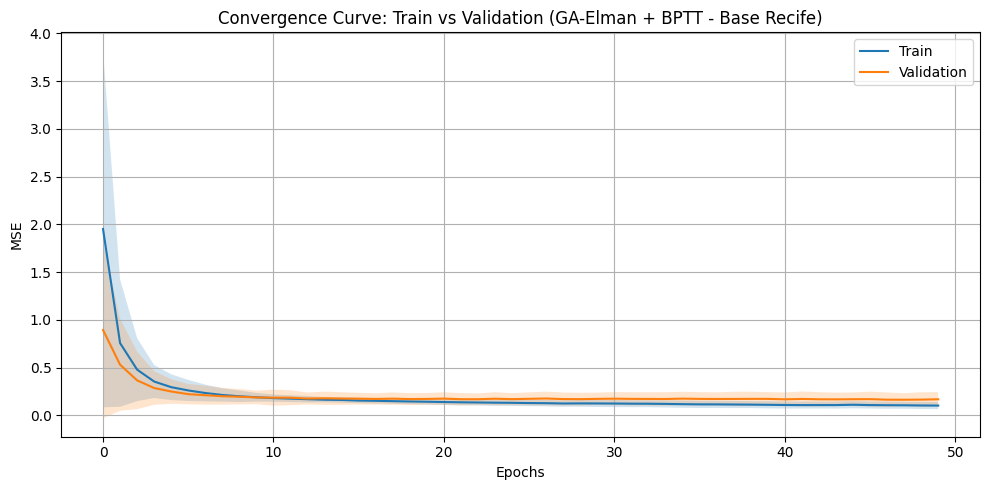


GA-Elman + BPTT training time (base Recife) : 12 minuts and 4 seconds.


In [ ]:
# Pipeline completo dos dados
X_train_rec, X_val_rec, X_test_rec, y_train_rec, y_val_rec, y_test_rec, scaler_rec = pipeline_dados(ts_rec, norm=True)

start_time_evornn = time.time()

resultados_ga_rnn_rec = ga_train_elman(
    X_train=X_train_rec,
    y_train=y_train_rec,
    X_val=X_val_rec,
    y_val=y_val_rec,
    X_test=X_test_rec,
    y_test=y_test_rec,
    pop_size=30,
    generations=20,
    n_execucao=30,
    n_epocas=50
)

(mse_medio_treino, mse_std_treino, mse_medio_val, mse_std_val, best_model_ga_rnn_rec, best_fitness_ga_rnn_rec, test_mses_ga_rnn_rec) = resultados_ga_rnn_rec

log_results("Recife", "GA_Elman_bptt", test_mses_ga_rnn_rec) # salva os MSEs das 30 execuções

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (GA-Elman + BPTT - Base Recife)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time_evornn = time.time()

elapsed_time_evornn = end_time_evornn - start_time_evornn
minutes_evornn = int(elapsed_time_evornn // 60)
seconds_evornn = int(elapsed_time_evornn % 60)

print(f"\nGA-Elman + BPTT training time (base Recife) : {minutes_evornn} minuts and {seconds_evornn} seconds.")

In [ ]:
print('GA-Elman + BPTT - Base Recife:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")
print(f"\nBest MSE validation: {best_fitness_ga_rnn_rec :.4}")

GA-Elman + BPTT - Base Recife:

MSE final training : 0.1012 +- 0.037 
MSE final validation: 0.167 +- 0.0749

Best MSE validation: 0.1167


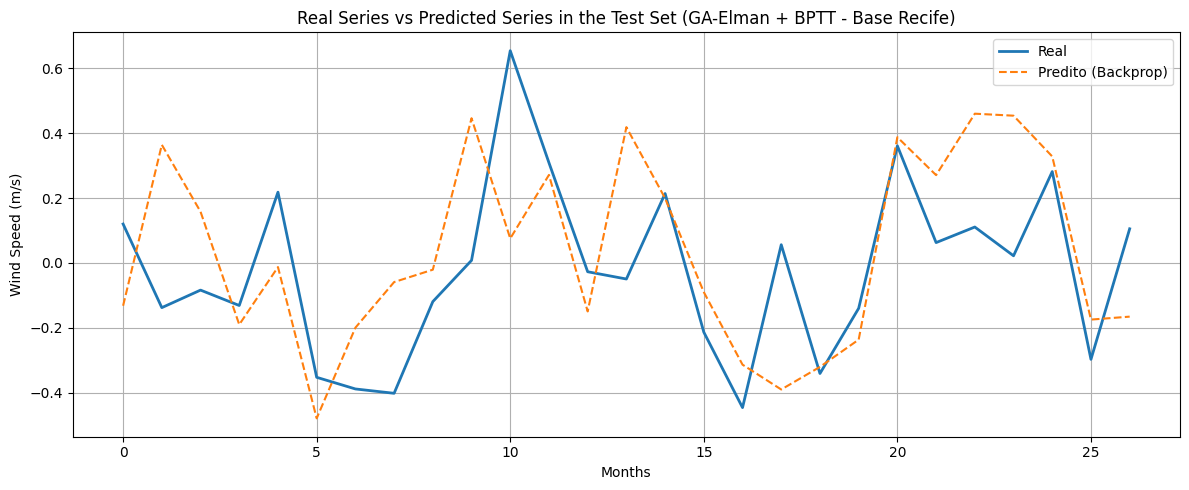

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_rec.shape[0]):
    x = X_test_rec[i,:,0]               # vetor de 12 valores
    preds.append(elman_predict(best_model_ga_rnn_rec, x))
y_pred_ga_rnn_rec = np.array(preds).reshape(-1)

# Inversão da normalização
y_pred_ga_rnn_real_rec = scaler_rec.inverse_transform(y_pred_ga_rnn_rec.reshape(-1, 1))
y_test_real_rec = scaler_rec.inverse_transform(y_test_rec.reshape(-1, 1))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_rec.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_rnn_real_rec.flatten(), label="Predito (Backprop)", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-Elman + BPTT - Base Recife)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_teste_ga_rnn_rec = mean_squared_error(y_test_real_rec, y_pred_ga_rnn_real_rec)

print('GA-Elman Network + BPTT - Base Recife')
print(f"\nMSE test: {mse_teste_ga_rnn_rec:.4f}")

GA-Elman Network + BPTT - Base Recife

MSE test: 0.0762


In [ ]:
# salva o array
np.save('y_pred_ga_elman_real_rec.npy', y_pred_ga_rnn_real_rec)

###### Plot geral (Recife)

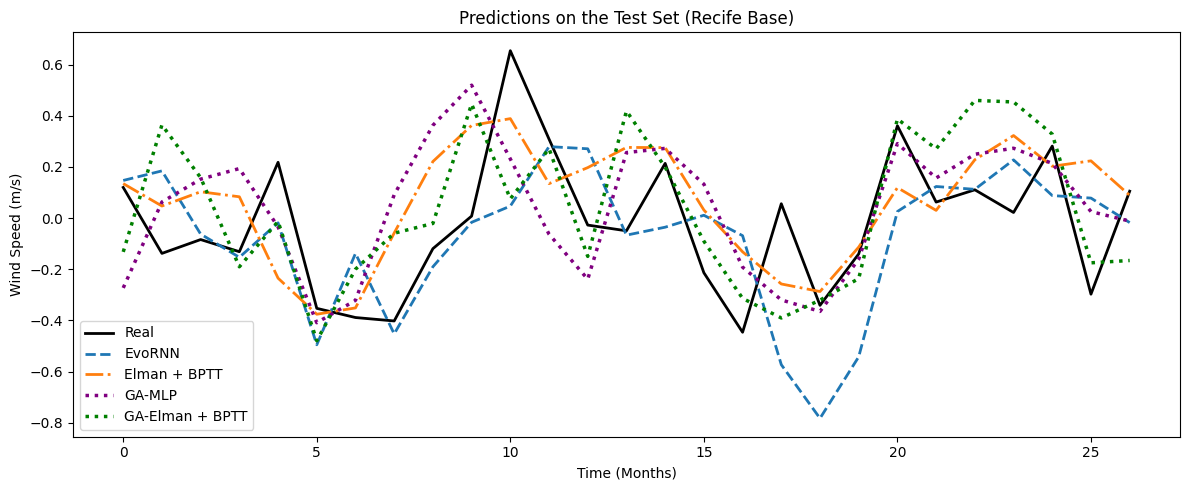

In [ ]:
plt.figure(figsize=(12, 5))

# Série real
plt.plot(y_test_real_rec.flatten(), label="Real", linewidth=2, color='black')

# Previsões
plt.plot(y_pred_evornn_real_rec.flatten(), label="EvoRNN", linestyle='--', linewidth=2)
plt.plot(y_pred_bptt_real_rec.flatten(), label="Elman + BPTT", linestyle='-.', linewidth=2)
plt.plot(y_pred_ga_mlp_real_rec, label="GA-MLP", linestyle=':', linewidth=2.5, color='purple')
plt.plot(y_pred_ga_elman_real_rec, label="GA-Elman + BPTT", linestyle=':', linewidth=2.5, color='green')

plt.title("Predictions on the Test Set (Recife Base)")
plt.xlabel("Time (Months)")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
print("Base Recife")
print(f"\nMSE test (EvoRNN): {mse_test_evornn_rec :.4f}")
print(f"MSE test (Elman + BPTT): {mse_teste_bptt_rec:.4f}")
print(f"MSE test (ARIMA): {mse_arima_rec:.4f}")

Base Recife

MSE test (EvoRNN): 0.0684
MSE test (Elman + BPTT): 0.0667
MSE test (ARIMA): 0.0478


##### Experimentos - Base Fortaleza

###### EvoRNN

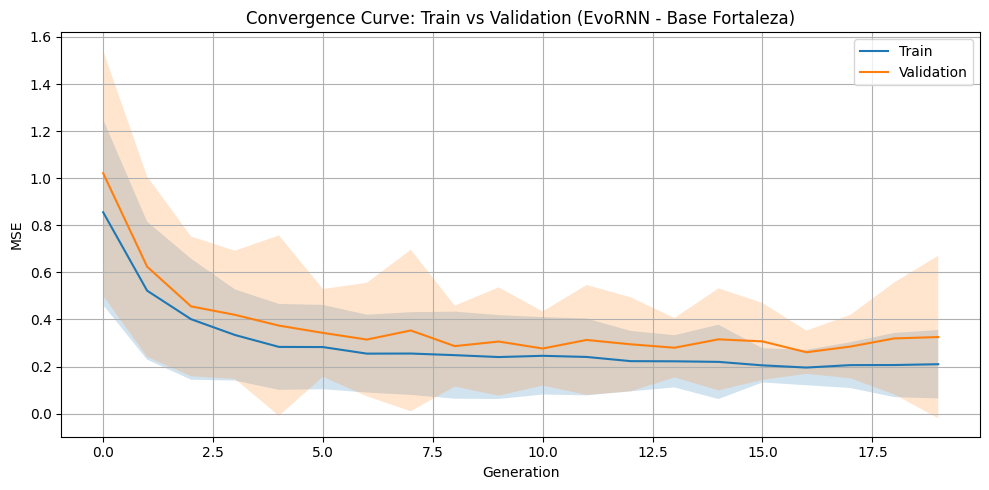


Evornn training time - Fortaleza : 156 minuts and 16 seconds.


In [ ]:
'''Para normalizar a série passada para a função 'pipeline_dados', setar 'norm=True' e adicionar 'scaler' após 'y'_test
   Em caso contrário, setar 'norm=False' e remover 'scaler' após 'y_test' '''

X_train_for, X_val_for, X_test_for, y_train_for, y_val_for, y_test_for, scaler_for = pipeline_dados(ts_for, norm=True)

# Cria o modelo base com entrada de 12 lags
modelo_base = criar_rnn(seq_len=12, unidades=20)
modelo_base.build(input_shape=(None, 12, 1))  # define o shape de entrada para uso em build()

# Dimensiona quantidade de pesos a serem evoluídos necessárias para o modelo
n_genes = sum(np.prod(w.shape) for w in modelo_base.get_weights())

start_time_evornn = time.time()

resultados_evornn_for = evoluir(
    fitness_func=fitness_rnn,
    mutacao_func=mut_gaussian,
    X_train=X_train_for,
    y_train=y_train_for,
    X_val=X_val_for,
    y_val=y_val_for,
    X_test=X_test_for,
    y_test=y_test_for,
    modelo_base=modelo_base,
    n_execucoes=30,
    n_gen=20,
    tamanho_pop=30,
    n_genes=n_genes
)

(h_treino, std_treino, final_treino,
 h_val, std_val, final_val, best_model_evornn_for, best_fitness_evornn_for, test_mses_evornn_for) = resultados_evornn_for

log_results("Fortaleza", "EvoRNN", test_mses_evornn_for) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (EvoRNN - Base Fortaleza)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time_evornn = time.time()

elapsed_time_evornn = end_time_evornn - start_time_evornn
minutes_evornn = int(elapsed_time_evornn // 60)
seconds_evornn = int(elapsed_time_evornn % 60)

print(f"\nEvornn training time - Fortaleza : {minutes_evornn} minuts and {seconds_evornn} seconds.")

In [ ]:
print('EvoRNN - Base Fortaleza:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.4} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.4}")
print(f"\nBest MSE validation: {best_fitness_evornn_for :.4}")

EvoRNN - Base Fortaleza:

MSE final training: 0.21 +- 0.1455 
MSE final validation: 0.3254 +- 0.3453

Best MSE validation: 0.1154


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


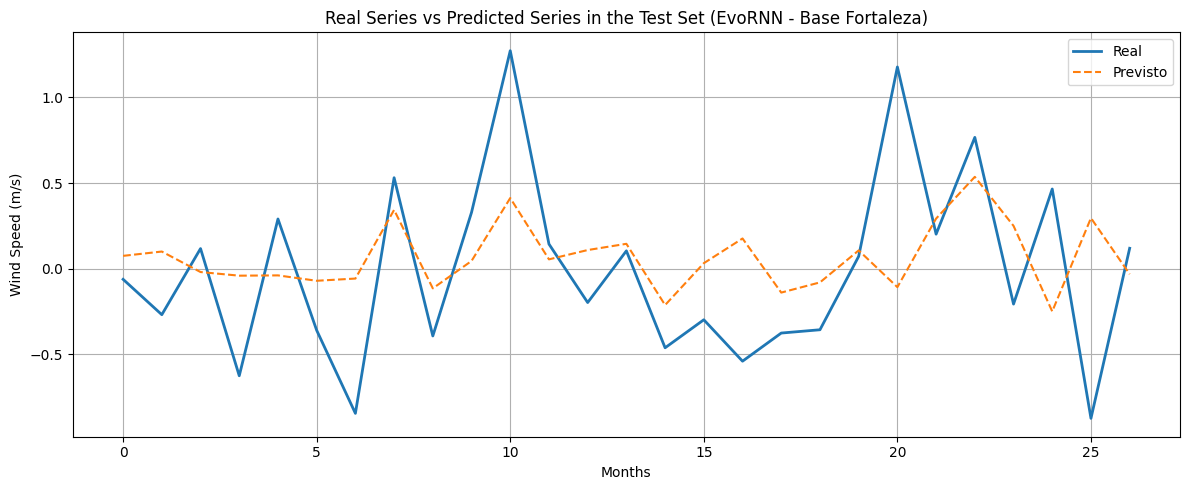

In [ ]:
evornn_for = tf.keras.models.clone_model(modelo_base)
evornn_for.build(input_shape=(None, X_test_for.shape[1], 1))

set_pesos(evornn_for, best_model_evornn_for)

# Prever a série de teste
y_pred_evornn_for = evornn_for.predict(X_test_for)

# Inverter a normalização para 'y_pred' e 'y_test'
y_pred_evornn_real_for = scaler_for.inverse_transform(y_pred_evornn_for)
y_test_real_for = scaler_for.inverse_transform(y_test_for)

plt.figure(figsize=(12, 5))
plt.plot(y_test_real_for.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_evornn_real_for.flatten(), label="Previsto", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (EvoRNN - Base Fortaleza)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_evornn_for  = mean_squared_error(y_test_real_for, y_pred_evornn_real_for)
print(f"MSE test (EvoRNN - Base Fortaleza): {mse_test_evornn_for :.5f}")

MSE test (EvoRNN - Base Fortaleza): 0.25930


In [ ]:
# Salva o array
np.save('y_pred_evornn_real_for.npy', y_pred_evornn_real_for)

###### Elman Network (otimização via gradiente)

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

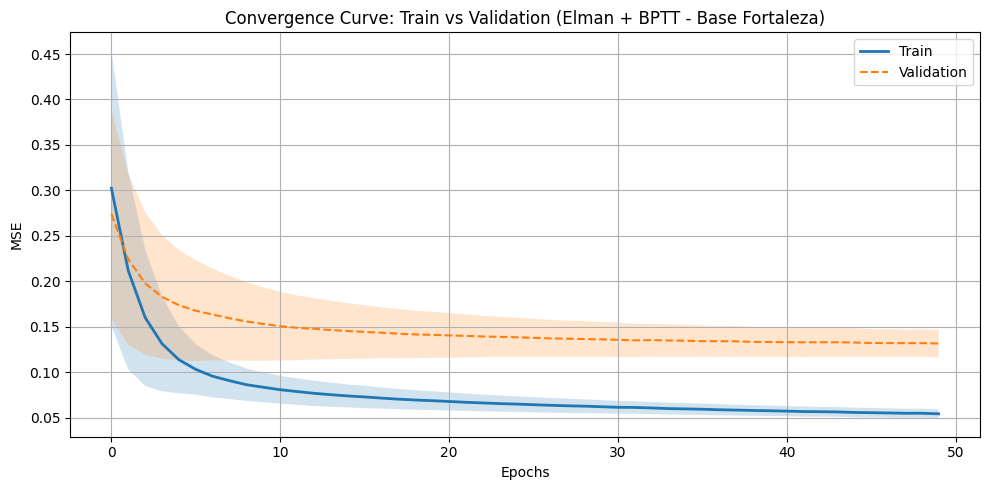

In [ ]:
n_execucoes = 30
n_epocas = 50
batch_size = 16
seed_base=1

# Matrizes para armazenar o histórico de perda por execução
historico_treino = np.zeros((n_execucoes, n_epocas))
historico_val = np.zeros((n_execucoes, n_epocas))
preds_bptt_for = []
test_mses_bptt_for = []

X_train_for, X_val_for, X_test_for, y_train_for, y_val_for, y_test_for, scaler_for = pipeline_dados(ts_for, norm=True)

for i in range(n_execucoes):
    #print(f"Execução {i+1}/{n_execucoes}")

    np.random.seed(seed_base + i) # para reprodutibilidade

    modelo_rnn_for = criar_rnn_backprop(seq_len=12, unidades=20, lr=0.001)

    history_rnn_for = modelo_rnn_for.fit(
        X_train_for, y_train_for,
        validation_data=(X_val_for, y_val_for),
        epochs=n_epocas,
        batch_size=batch_size,
        verbose=0
    )

    historico_treino[i, :] = history_rnn_for.history['loss']
    historico_val[i, :] = history_rnn_for.history['val_loss']

    # predict para cada 'n_execucoes'
    y_pred_bptt_for = modelo_rnn_for.predict(X_test_for)
    preds_bptt_for.append(y_pred_bptt_for)

    # MSEs para cada 'n_execucoes'
    mse_test_bptt_for = MeanSquaredError()(y_test_for, y_pred_bptt_for).numpy()
    test_mses_bptt_for.append(mse_test_bptt_for)

log_results("Fortaleza", "Elman_bptt", test_mses_bptt_for) # salva os MSEs das 30 execuções

# Cálculo da média e do desvio padrão
mse_medio_treino = np.mean(historico_treino, axis=0)
mse_std_treino = np.std(historico_treino, axis=0)

mse_medio_val = np.mean(historico_val, axis=0)
mse_std_val = np.std(historico_val, axis=0)

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train", linewidth=2)
plt.fill_between(range(n_epocas), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation", linestyle='--')
plt.fill_between(range(n_epocas), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (Elman + BPTT - Base Fortaleza)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print('Elman + BPTT - Base Fortaleza:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")

Elman + BPTT - Base Fortaleza:

MSE final training : 0.0542 +- 0.005 
MSE final validation: 0.1316 +- 0.0152


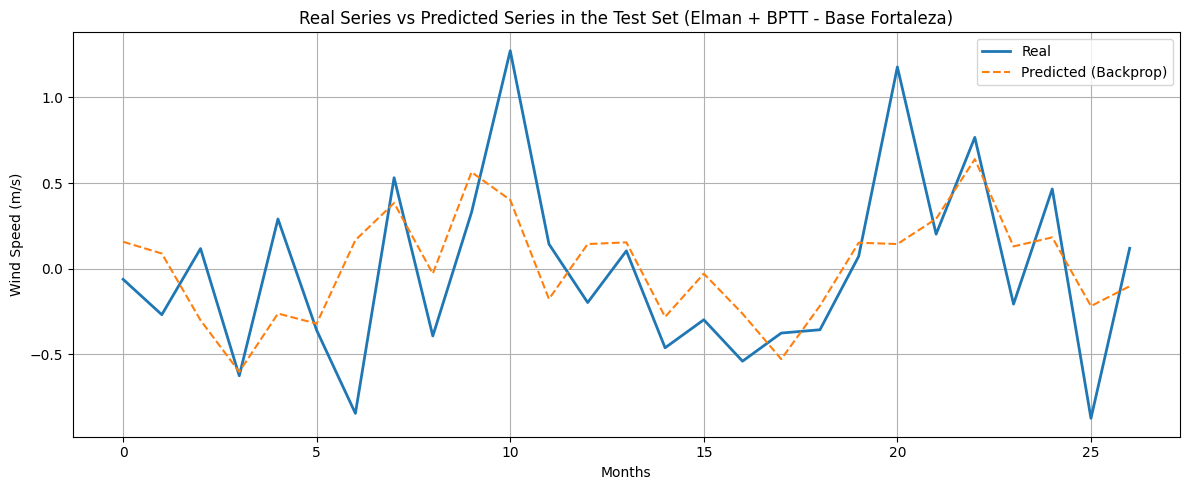

In [ ]:
# média das predições das 'n_execucoes'
y_mean_preds_for = np.mean(preds_bptt_for, axis=0)

# Inversão da normalização
y_pred_bptt_real_for = scaler_for.inverse_transform(y_mean_preds_for)
y_test_real_for = scaler_for.inverse_transform(y_test_for)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_for.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_bptt_real_for.flatten(), label="Predicted (Backprop)", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (Elman + BPTT - Base Fortaleza)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_bptt_for = mean_squared_error(y_test_real_for, y_pred_bptt_real_for)

print('Elman Network + BPTT - Base Recife')
print(f"\nMSE test: {mse_test_bptt_for:.4f}")

Elman Network + BPTT - Base Recife

MSE test: 0.1802


In [ ]:
# Save the array to a file named 'y_pred_data.npy'
np.save('y_pred_bptt_real_for.npy', y_pred_bptt_real_for)

###### GA-MLP

In [ ]:
# ———————————————————————————————————————————————————————————————————————
# 1) Funções auxiliares para o MLP 12–2–1
# ———————————————————————————————————————————————————————————————————————

def mlp_predict(individual, x):
    """
    Dada uma janela x (shape=(12,)), e o vetor plano de pesos `individual`
    (length = 2*(12+1) + 1*(2+1) = 29), devolve a predição escalar y.
    Arquitetura: 12 inputs → 2 hidden tanh → 1 saída linear.
    """
    # Decodifica o vetor de genes em W1, b1, W2, b2
    #  1) entrada→oculta
    offset = 0
    W1 = individual[offset:offset+2*12].reshape(2,12); offset += 2*12
    b1 = individual[offset:offset+2];          offset += 2
    #  2) oculta→saída
    W2 = individual[offset:offset+2*1].reshape(1,2); offset += 2*1
    b2 = individual[offset]                      # offset += 1

    # forwarding
    h = np.tanh(W1.dot(x) + b1)      # shape (2,)
    y = W2.dot(h) + b2               # shape (1,)

    return y.flatten()

def fitness_mlp(individual, X, y):
    """
    Fitness = RMSE no conjunto (X,y). Aqui usamos MSE para seleção (menor melhor).
      X: shape (n_samples, 12, 1)
      y: shape (n_samples, 1)
    """
    preds = []
    for i in range(X.shape[0]):
        x = X[i,:,0]               # vetor de 12 valores
        preds.append( mlp_predict(individual, x) )
    preds = np.array(preds).reshape(-1)
    true  = y.reshape(-1)
    return mean_squared_error(true, preds)   # RMSE (TROCAR PARA MSE, apenas apagar 0.5)

# ———————————————————————————————————————————————————————————————————————
# 2) Operadores genéticos
# ———————————————————————————————————————————————————————————————————————

def one_point_crossover(p1, p2):
    size = len(p1)
    pt = np.random.randint(1, size)      # ponto de corte entre 1 e size-1
    child = np.empty_like(p1)
    child[:pt] = p1[:pt]
    child[pt:] = p2[pt:]
    return child

# esse operador é o análogo real-codificado do bit flip com probabilidade 0.3 do GA original
# com adição de ruído gaussiano nos genes a serem mutados
def mutation(p, mut_prob=0.3, sigma=0.1):
    """
    Mutação por ruído gaussiano: para cada gene, com prob=mut_prob,
    adiciona-se N(0, sigma²).
    """
    mask = np.random.rand(len(p)) < mut_prob # marca cada gene que vai sofrer mutação
    noise = np.random.normal(0, sigma, size=len(p))
    child = p.copy()
    child[mask] += noise[mask] # adiciona ruído gaussiano apenas nos genes marcados
    return child

# ———————————————————————————————————————————————————————————————————————
# 3) O GA principal
# ———————————————————————————————————————————————————————————————————————

def ga_train_mlp(X_train, y_train, X_val, y_val, X_test, y_test, input_size=12, hidden_size=2, output_size=1,
    pop_size=50, generations=10, crossover_prob=0.7, mutation_prob=0.3, sigma=0.1, n_execucao=10, seed_base=1):

    historico_exec_treino = []
    historico_exec_val = []
    test_mses = []

    best_global = None
    best_fitness_global = np.inf

    # Armazena o melhor MSE da validação e o indivíduo
    #best_val_mse = np.inf
    #best_ind   = None

    n_genes = hidden_size*(input_size+1) + output_size*(hidden_size+1)

    for execucao in range(n_execucao):
        np.random.seed(seed_base + execucao) # para reprodutibilidade

        # 3.1) inicialização da população
        pop = np.random.uniform(-1, 1, (pop_size, n_genes))

        historico_treino = []
        historico_val = []

        # Armazena o melhor MSE da validação e o indivíduo da execução
        # Reseta ao inicio de cada 'n_execucao'
        best_val_mse = np.inf
        best_ind   = None

        # Guarda cópia para possível revert
        prev_pop = pop.copy()

        gen = 0
        while gen < generations:
            # ——————————————————————————————————————————
            # 3.a–3.b) Para cada cromossomo: mutation, crossover, seleção
            # ——————————————————————————————————————————
            new_pop = np.empty_like(pop)
            for i in range(pop_size):
                parent = pop[i]
                # escolhe dois outros pais aleatórios
                a, b = np.random.choice(pop_size, 2, replace=False)
                p1, p2 = pop[a], pop[b]

                # mutation + crossover → trial
                trial = parent.copy()
                if np.random.rand() < crossover_prob:
                    trial = one_point_crossover(p1, p2)
                trial = mutation(trial, mut_prob=mutation_prob, sigma=sigma)

                # 3.d) avaliação de fitness
                fit_parent = fitness_mlp(parent, X_train, y_train) # sem mutação/crossover
                fit_trial  = fitness_mlp(trial,  X_train, y_train) # pode ter sofrido mutação/crossover ou não
                # 3.e) seleciona trial se tiver fitness melhor que parent
                new_pop[i] = trial if fit_trial < fit_parent else parent

            # ——————————————————————————————————————————
            # 3.f) avalia melhor da nova população em VALIDAÇÃO
            # ——————————————————————————————————————————
            # encontra MSE de cada indivíduo no treino
            train_mses = np.array([fitness_mlp(ind, X_train, y_train) for ind in new_pop])
            idx_min_train   = np.argmin(train_mses) # pega o indice de menor (melhor) fitness no treino
            cur_best_train  = train_mses[idx_min_train] # localiza o melhor fitness no treino

            # encontra MSE de cada indivíduo na validação
            val_mses = np.array([fitness_mlp(ind, X_val, y_val) for ind in new_pop])
            idx_min   = np.argmin(val_mses) # pega o indice de menor (melhor) fitness
            cur_best  = val_mses[idx_min] # localiza o melhor fitness

            if cur_best <= best_val_mse:
                # aceita geração e atualiza “melhor”
                best_val_mse = cur_best
                best_ind = new_pop[idx_min].copy()
                pop = new_pop # nova população atualizada
                prev_pop = pop.copy()
                gen += 1

                # Só atualiza o histórico se a geração for aceita
                historico_treino.append(cur_best_train)
                historico_val.append(cur_best)
                #print(f" Geração {gen:3d} → Val_RMSE improved to {best_val_mse:.4f}")
            else:
                # rejeita e “volta” à população anterior (passo 3.b)
                pop = prev_pop.copy()
                #print(f" Geração {gen+1:3d} → Val_RMSE worsened ({cur_best:.4f}), regenerating…

        # FAZER AQUI O PREDICT NO TESTE COM O 'best_ind' DA EXECUÇÃO
        # Deve ser feito antes do 'if' abaixo, pois 'best_val_mse' (e, portanto o 'best_ind') da 'n_execucao[t]'
        # pode não superar o 'best_val_mse' da 'n_execucao[t-1]' (ou seja, 'best_fitness_global'). Assim
        # garantimos que o predict no teste será feito com o 'best_ind' da execução atual.
        fitness_test = fitness_mlp(best_ind, X_test, y_test)
        test_mses.append(fitness_test)

        # armazena os genes do melhor indivíduo geral para todo 'n_execucao' e 'n_gen'
        if best_val_mse < best_fitness_global:
          best_model_global = best_ind.copy()
          best_fitness_global = best_val_mse

        # armazena os históricos de treino e validação de cada 'n_execucao'
        historico_exec_treino.append(historico_treino)
        historico_exec_val.append(historico_val)

    # Métricas de treino
    historico_exec_treino = np.array(historico_exec_treino)
    historico_medio_treino = np.mean(historico_exec_treino, axis=0)
    desvio_padrao_treino = np.std(historico_exec_treino, axis=0)
    media_final_treino = np.mean(historico_exec_treino[:, -1])

    # Métricas de validação
    historico_exec_val = np.array(historico_exec_val)
    historico_medio_val = np.mean(historico_exec_val, axis=0)
    desvio_padrao_val = np.std(historico_exec_val, axis=0)
    media_final_val = np.mean(historico_exec_val[:, -1])

    return (historico_medio_treino, desvio_padrao_treino, media_final_treino,
           historico_medio_val, desvio_padrao_val, media_final_val, best_model_global, best_fitness_global, test_mses)

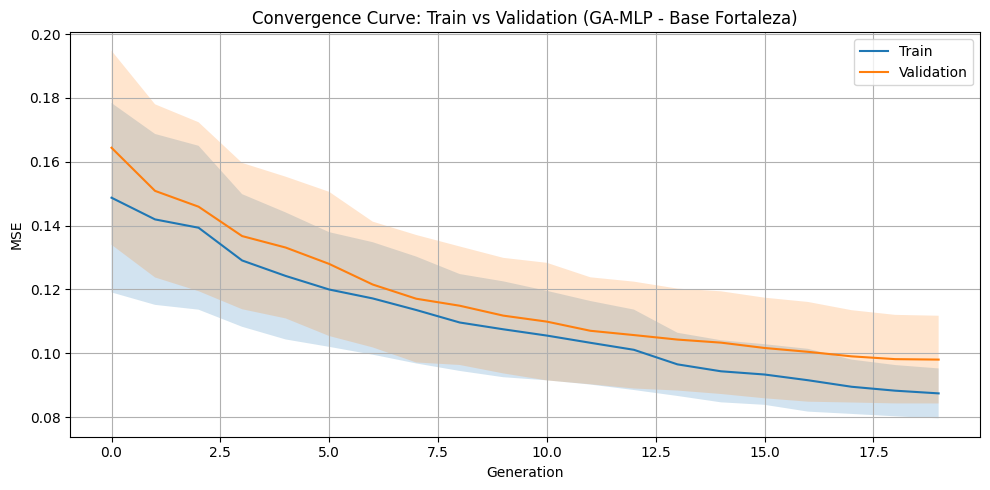

NameError: name 'minutes_evornn' is not defined

In [ ]:

start_time = time.time()

resultados_ga_mlp_for = ga_train_mlp(
    X_train=X_train_for,
    y_train=y_train_for,
    X_val=X_val_for,
    y_val=y_val_for,
    X_test=X_test_for,
    y_test=y_test_for,
    pop_size=30,
    generations=20,
    n_execucao=30
)

(h_treino, std_treino, final_treino, h_val, std_val, final_val, best_model_ga_mlp_for,
 best_fitness_ga_mlp_for, test_mses_ga_mlp_for) = resultados_ga_mlp_for

log_results("Fortaleza", "GA_MLP", test_mses_ga_mlp_for) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (GA-MLP - Base Fortaleza)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time = time.time()

elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\nGA-MLP training time (base Fortaleza) : {minutes} minuts and {seconds} seconds.")

In [ ]:
print('GA-MLP - Base Fortaleza:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.2} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.3}")
print(f"\nBest MSE validation: {best_fitness_ga_mlp_for:.4}")

GA-MLP - Base Fortaleza:

MSE final training: 0.08746 +- 0.0078 
MSE final validation: 0.09804 +- 0.0137

Best MSE validation: 0.06997


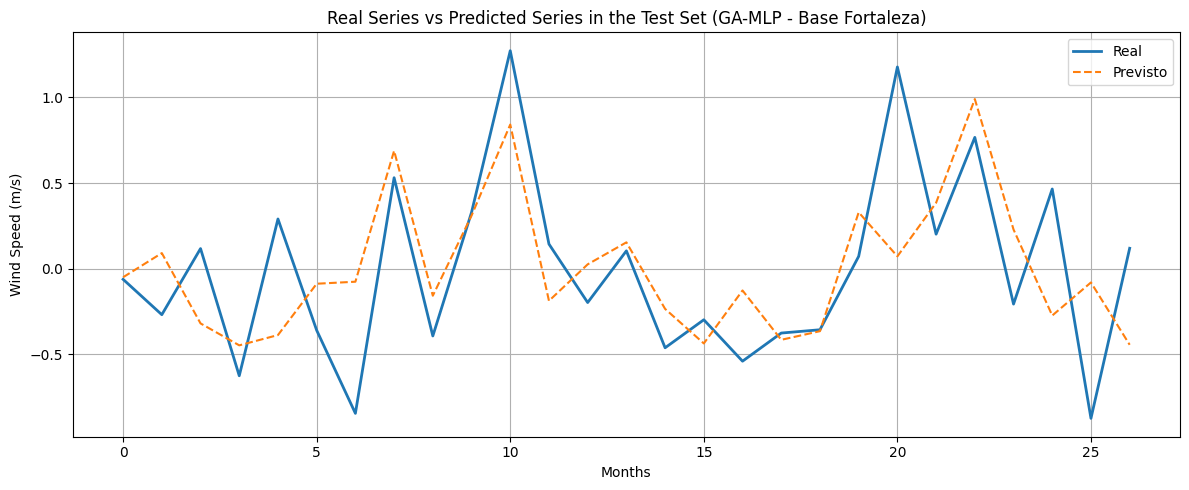

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_for.shape[0]):
    x = X_test_for[i,:,0]               # vetor de 12 valores
    preds.append(mlp_predict(best_model_ga_mlp_for, x))
y_pred_ga_mlp_for = np.array(preds).reshape(-1)

# desnormalizar as predições e o target
y_pred_ga_mlp_real_for = scaler_for.inverse_transform(y_pred_ga_mlp_for.reshape(-1, 1))
y_test_real_for = scaler_for.inverse_transform(y_test_for.reshape(-1, 1))

# plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_for.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_mlp_real_for.flatten(), label="Previsto", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-MLP - Base Fortaleza)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_ga_mlp_for  = mean_squared_error(y_test_real_for, y_pred_ga_mlp_real_for)
print(f"MSE test (GA-MLP - Base Fortaleza): {mse_test_ga_mlp_for :.4f}")

MSE test (GA-MLP - Base Fortaleza): 0.1926


In [ ]:
# salva o array
np.save('y_pred_ga_mlp_real_for.npy', y_pred_ga_mlp_real_for)

###### GA-Elman

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not p

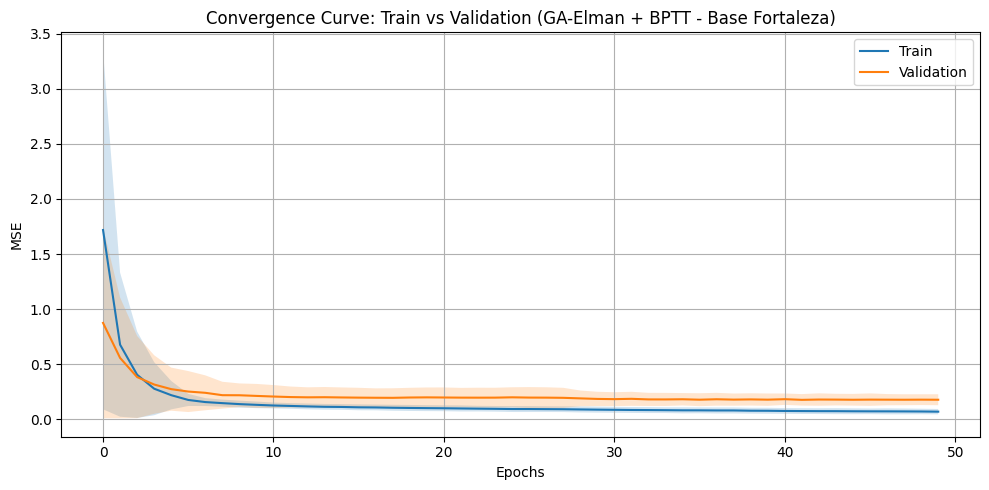


GA-Elman + BPTT training time (base Fortaleza) : 12 minuts and 40 seconds.


In [ ]:
start_time = time.time()

resultados_ga_rnn_for = ga_train_elman(
    X_train=X_train_for,
    y_train=y_train_for,
    X_val=X_val_for,
    y_val=y_val_for,
    X_test=X_test_for,
    y_test=y_test_for,
    pop_size=30,
    generations=20,
    n_execucao=30,
    n_epocas=50
)

(mse_medio_treino, mse_std_treino, mse_medio_val, mse_std_val, best_model_ga_rnn_for, best_fitness_ga_rnn_for, test_mses_ga_rnn_for) = resultados_ga_rnn_for

log_results("Fortaleza", "GA_Elman_bptt", test_mses_ga_rnn_for) # salva os MSEs das 30 execuções

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (GA-Elman + BPTT - Base Fortaleza)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time = time.time()

elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\nGA-Elman + BPTT training time (base Fortaleza) : {minutes} minuts and {seconds} seconds.")

In [ ]:
print('GA-Elman + BPTT - Base Fortaleza:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")
print(f"\nBest MSE validation: {best_fitness_ga_rnn_for :.4}")

GA-Elman + BPTT - Base Fortaleza:

MSE final training : 0.0701 +- 0.0243 
MSE final validation: 0.1782 +- 0.0498

Best MSE validation: 0.1094


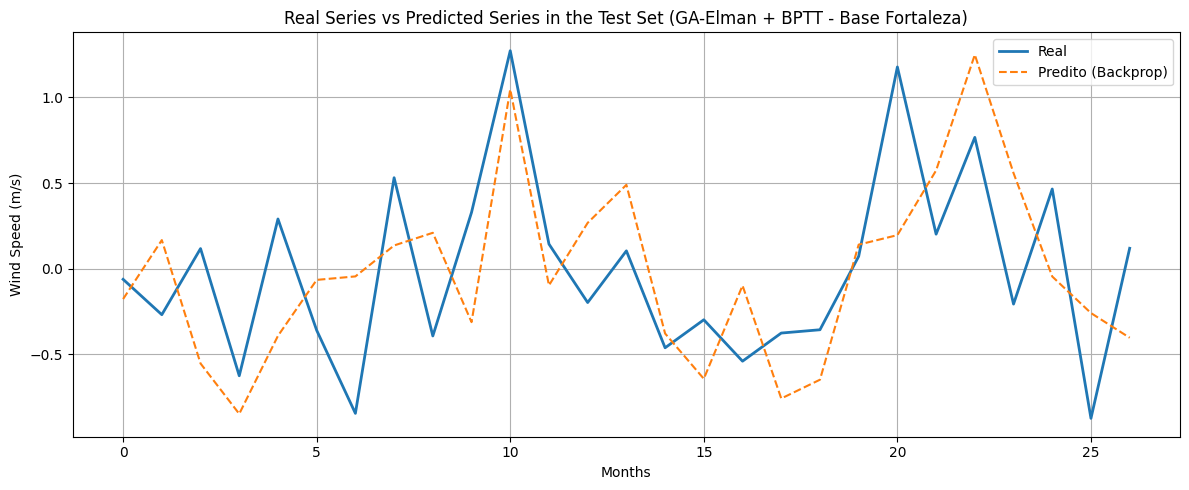

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_for.shape[0]):
    x = X_test_for[i,:,0]               # vetor de 12 valores
    preds.append(elman_predict(best_model_ga_rnn_for, x))
y_pred_ga_rnn_for = np.array(preds).reshape(-1)

# Inversão da normalização
y_pred_ga_rnn_real_for = scaler_for.inverse_transform(y_pred_ga_rnn_for.reshape(-1, 1))
y_test_real_for = scaler_for.inverse_transform(y_test_for.reshape(-1, 1))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_for.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_rnn_real_for.flatten(), label="Predito (Backprop)", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-Elman + BPTT - Base Fortaleza)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_teste_ga_rnn_for = mean_squared_error(y_test_real_for, y_pred_ga_rnn_real_for)

print('GA-Elman Network + BPTT - Base Fortaleza')
print(f"\nMSE test: {mse_teste_ga_rnn_for:.4f}")

GA-Elman Network + BPTT - Base Fortaleza

MSE test: 0.2475


In [ ]:
# salva o array
np.save('y_pred_ga_elman_real_for.npy', y_pred_ga_rnn_real_for)

###### Plot Geral (Fortaleza)

In [ ]:
# carrega das predições para Fortaleza
y_pred_evornn_real_for = np.load('y_pred_evornn_real_for.npy')
y_pred_bptt_real_for = np.load('y_pred_bptt_real_for.npy')
y_pred_ga_mlp_real_for = np.load('y_pred_ga_mlp_real_for.npy')
y_pred_ga_elman_real_for = np.load('y_pred_ga_elman_real_for.npy')

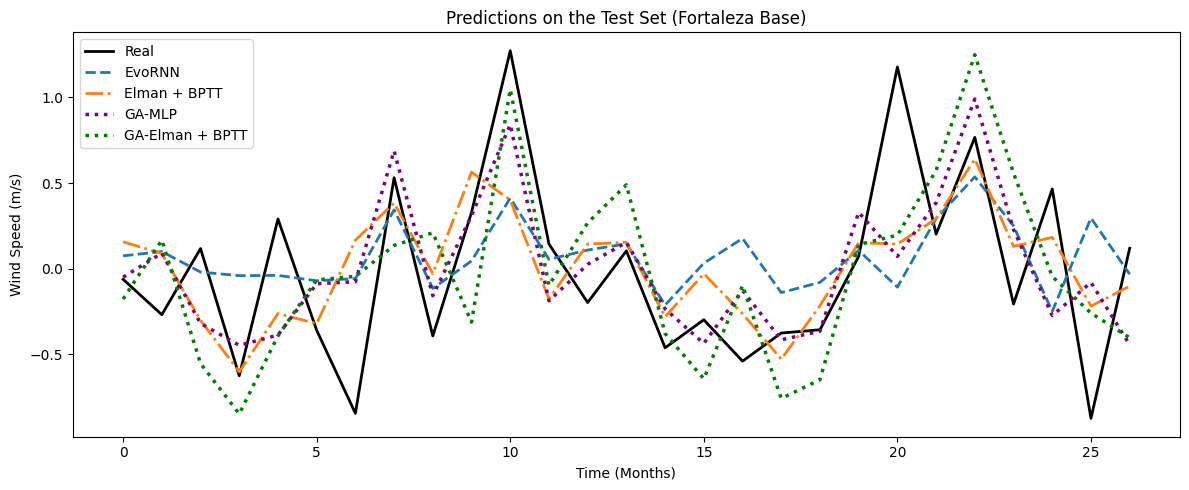

In [ ]:
plt.figure(figsize=(12, 5))

# Série real
plt.plot(y_test_real_for.flatten(), label="Real", linewidth=2, color='black')

# Previsões
plt.plot(y_pred_evornn_real_for.flatten(), label="EvoRNN", linestyle='--', linewidth=2)
plt.plot(y_pred_bptt_real_for.flatten(), label="Elman + BPTT", linestyle='-.', linewidth=2)
plt.plot(y_pred_ga_mlp_real_for, label="GA-MLP", linestyle=':', linewidth=2.5, color='purple')
plt.plot(y_pred_ga_elman_real_for, label="GA-Elman + BPTT", linestyle=':', linewidth=2.5, color='green')

plt.title("Predictions on the Test Set (Fortaleza Base)")
plt.xlabel("Time (Months)")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

##### Experimentos - Base Natal

###### EvoRNN

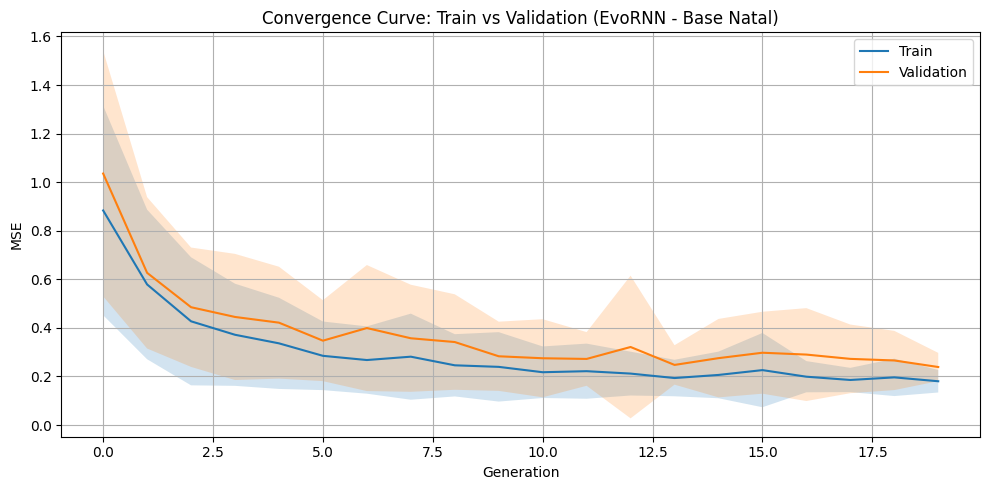


Evornn training time : 170 minuts and 12 seconds.


In [ ]:
'''Para normalizar a série passada para a função 'pipeline_dados', setar 'norm=True' e adicionar 'scaler' após 'y'_test
   Em caso contrário, setar 'norm=False' e remover 'scaler' após 'y_test' '''

X_train_nat, X_val_nat, X_test_nat, y_train_nat, y_val_nat, y_test_nat, scaler_nat = pipeline_dados(ts_nat, norm=True)

# Cria o modelo base com entrada de 12 lags
modelo_base = criar_rnn(seq_len=12, unidades=20)
modelo_base.build(input_shape=(None, 12, 1))  # define o shape de entrada para uso em build()

# Dimensiona quantidade de pesos a serem evoluídos necessárias para o modelo
n_genes = sum(np.prod(w.shape) for w in modelo_base.get_weights())

start_time_evornn = time.time()

resultados_evornn_nat = evoluir(
    fitness_func=fitness_rnn,
    mutacao_func=mut_gaussian,
    X_train=X_train_nat,
    y_train=y_train_nat,
    X_val=X_val_nat,
    y_val=y_val_nat,
    X_test=X_test_nat,
    y_test=y_test_nat,
    modelo_base=modelo_base,
    n_execucoes=30,
    n_gen=20,
    tamanho_pop=30,
    n_genes=n_genes
)

(h_treino, std_treino, final_treino,
 h_val, std_val, final_val, best_model_evornn_nat, best_fitness_evornn_nat, test_mses_evornn_nat) = resultados_evornn_nat

log_results("Natal", "EvoRNN", test_mses_evornn_nat) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (EvoRNN - Base Natal)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time_evornn = time.time()

elapsed_time_evornn = end_time_evornn - start_time_evornn
minutes_evornn = int(elapsed_time_evornn // 60)
seconds_evornn = int(elapsed_time_evornn % 60)

print(f"\nEvornn training time : {minutes_evornn} minuts and {seconds_evornn} seconds.")

In [ ]:
print('EvoRNN - Base Natal:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.2} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.3}")
print(f"\nBest MSE validation: {best_fitness_evornn_nat :.4}")

EvoRNN - Base Natal:

MSE final training: 0.1803 +- 0.046 
MSE final validation: 0.2389 +- 0.0582

Best MSE validation: 0.1482


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


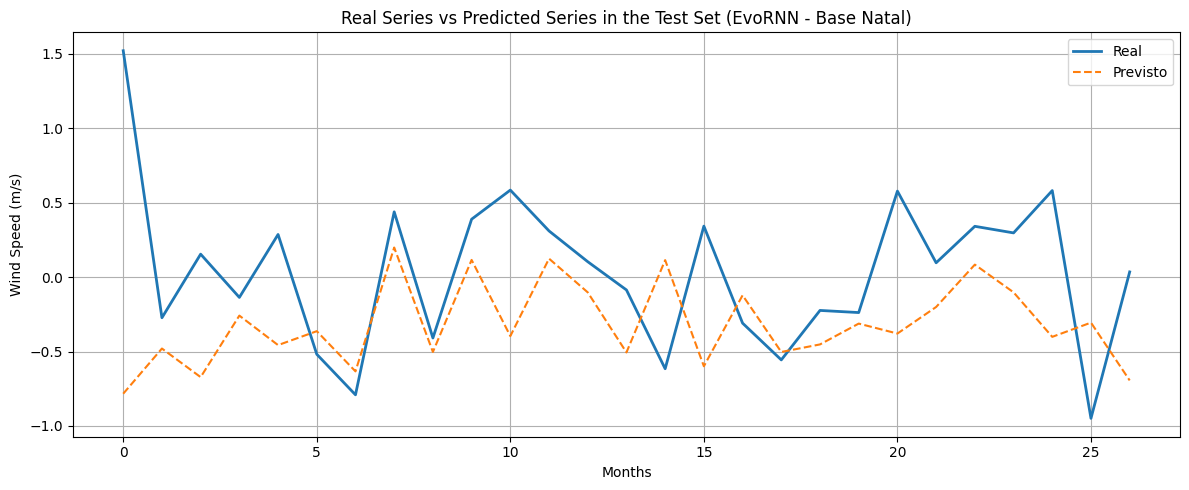

In [ ]:
# Criar modelo com mesma arquitetura
evornn_nat = tf.keras.models.clone_model(modelo_base)
evornn_nat.build(input_shape=(None, X_test_nat.shape[1], 1))

# Aplicar os melhores pesos evoluídos
set_pesos(evornn_nat, best_model_evornn_nat)

# Prever a série de teste
y_pred_evornn_nat = evornn_nat.predict(X_test_nat)

# Inverter a normalização para 'y_pred' e 'y_test'
y_pred_evornn_real_nat = scaler_nat.inverse_transform(y_pred_evornn_nat)
y_test_real_nat = scaler_nat.inverse_transform(y_test_nat)

plt.figure(figsize=(12, 5))
plt.plot(y_test_real_nat.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_evornn_real_nat.flatten(), label="Previsto", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (EvoRNN - Base Natal)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_evornn_nat = mean_squared_error(y_test_real_nat, y_pred_evornn_real_nat)
print(f"MSE test (EvoRNN- Base Natal): {mse_test_evornn_nat:.5f}")

MSE test (EvoRNN- Base Natal): 0.46847


In [ ]:
# Salva o array
np.save('y_pred_evornn_real_nat.npy', y_pred_evornn_real_nat)

###### Elman Network (otimização via gradiente)

Execução 1/30


c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Execução 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Execução 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Execução 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Execução 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Execução 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Execução 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
Execução 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Execução 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Execução 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Execução 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Execução 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Execução 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Execução 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Execução 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Execução 16/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Execução 17/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Execução 18/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Execução 19/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/st

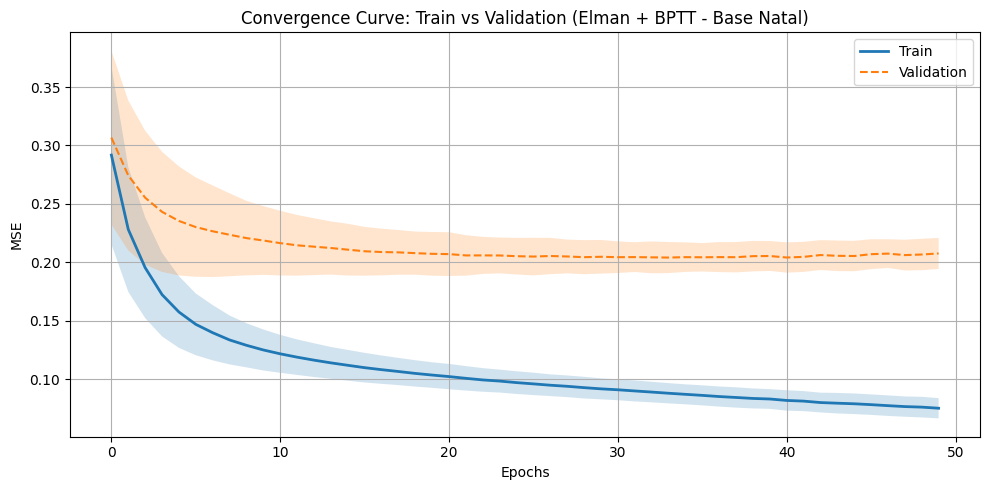

In [ ]:
n_execucoes = 30
n_epocas = 50
batch_size = 16
seed_base = 1

# Matrizes para armazenar o histórico de perda por execução
historico_treino = np.zeros((n_execucoes, n_epocas))
historico_val = np.zeros((n_execucoes, n_epocas))
preds_bptt_nat = []
test_mses_bptt_nat = []

#X_train, X_val, X_test, y_train, y_val, y_test, scaler = pipeline_dados(ts_nat, norm=True)

for i in range(n_execucoes):
    print(f"Execução {i+1}/{n_execucoes}")

    np.random.seed(seed_base + i) # para reprodutibilidade

    modelo_rnn_nat = criar_rnn_backprop(seq_len=12, unidades=20, lr=0.001)

    history_rnn_nat = modelo_rnn_nat.fit(
        X_train_nat, y_train_nat,
        validation_data=(X_val_nat, y_val_nat),
        epochs=n_epocas,
        batch_size=batch_size,
        verbose=0
    )

    historico_treino[i, :] = history_rnn_nat.history['loss']
    historico_val[i, :] = history_rnn_nat.history['val_loss']

    # predict para cada 'n_execucoes'
    y_pred_bptt_nat = modelo_rnn_nat.predict(X_test_nat)
    preds_bptt_nat.append(y_pred_bptt_nat)

    # MSEs para cada 'n_execucoes'
    mse_test_bptt_nat = MeanSquaredError()(y_test_nat, y_pred_bptt_nat).numpy()
    test_mses_bptt_nat.append(mse_test_bptt_nat)

log_results("Natal", "Elman_bptt", test_mses_bptt_nat) # salva os MSEs das 30 execuções

# Cálculo da média e do desvio padrão
mse_medio_treino = np.mean(historico_treino, axis=0)
mse_std_treino = np.std(historico_treino, axis=0)

mse_medio_val = np.mean(historico_val, axis=0)
mse_std_val = np.std(historico_val, axis=0)

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train", linewidth=2)
plt.fill_between(range(n_epocas), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation", linestyle='--')
plt.fill_between(range(n_epocas), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (Elman + BPTT - Base Natal)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print('Elman + BPTT - Base Natal:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")

Elman + BPTT - Base Natal:

MSE final training : 0.0752 +- 0.0086 
MSE final validation: 0.2076 +- 0.0133


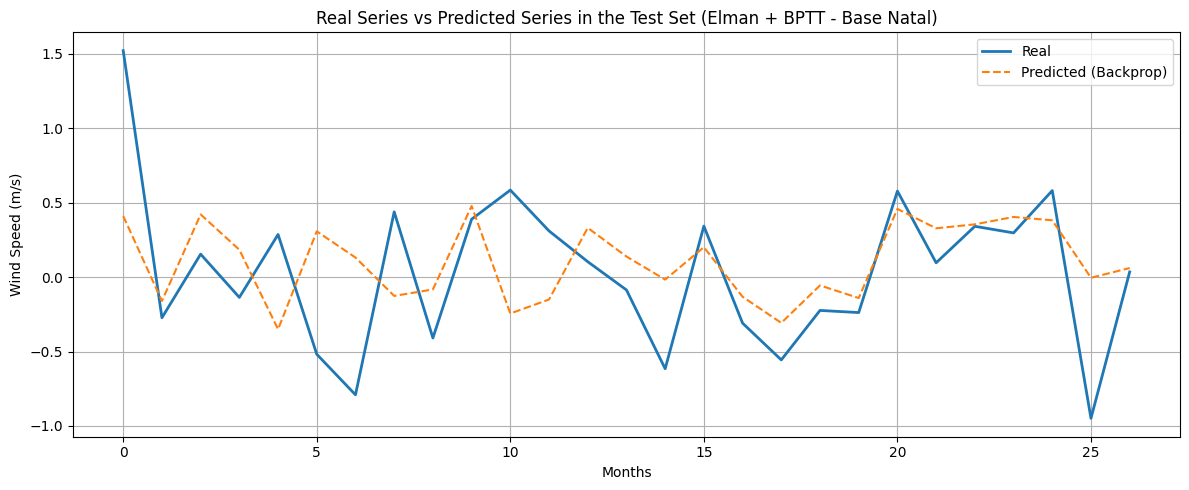

In [ ]:
# média das predições das 'n_execucoes'
y_mean_preds_nat = np.mean(preds_bptt_nat, axis=0)

# Inversão da normalização
y_pred_bptt_real_nat = scaler_nat.inverse_transform(y_mean_preds_nat)
y_test_real_nat = scaler_nat.inverse_transform(y_test_nat)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_nat.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_bptt_real_nat.flatten(), label="Predicted (Backprop)", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (Elman + BPTT - Base Natal)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_bptt_nat = mean_squared_error(y_test_real_nat, y_pred_bptt_real_nat)

print('Elman Network + BPTT - Base Natal')
print(f"\nMSE test: {mse_test_bptt_nat:.4f}")

Elman Network + BPTT - Base Natal

MSE test: 0.2336


In [ ]:
np.save('y_pred_bptt_real_nat.npy', y_pred_bptt_real_nat)

###### GA-MLP

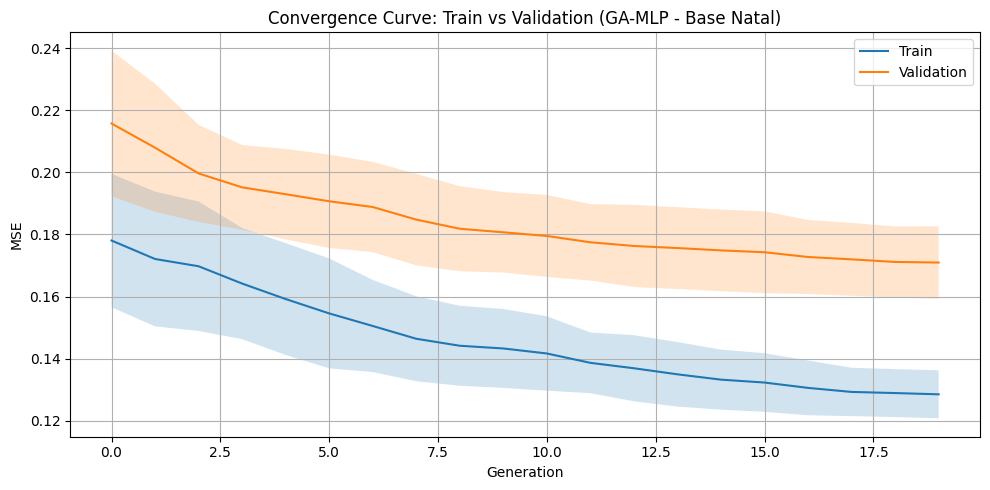


GA-MLP training time (base Natal) : 2 minuts and 21 seconds.


In [ ]:
start_time = time.time()

resultados_ga_mlp_nat = ga_train_mlp(
    X_train=X_train_nat,
    y_train=y_train_nat,
    X_val=X_val_nat,
    y_val=y_val_nat,
    X_test=X_test_nat,
    y_test=y_test_nat,
    pop_size=30,
    generations=20,
    n_execucao=30
)

(h_treino, std_treino, final_treino, h_val, std_val, final_val, best_model_ga_mlp_nat,
 best_fitness_ga_mlp_nat, test_mses_ga_mlp_nat) = resultados_ga_mlp_nat

log_results("Natal", "GA_MLP", test_mses_ga_mlp_nat) # salva os MSEs das 30 execuções

# Plote das curvas de convergências
plt.figure(figsize=(10, 5))
plt.plot(h_treino, label="Train")
plt.fill_between(range(len(h_treino)), h_treino - std_treino, h_treino + std_treino, alpha=0.2)
plt.plot(h_val, label="Validation")
plt.fill_between(range(len(h_val)), h_val - std_val, h_val + std_val, alpha=0.2)
plt.title("Convergence Curve: Train vs Validation (GA-MLP - Base Natal)")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time = time.time()

elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\nGA-MLP training time (base Natal) : {minutes} minuts and {seconds} seconds.")

In [ ]:
print('GA-MLP - Base Natal:')
print(f"\nMSE final training: {final_treino :.4} +- {std_treino[-1] :.2} \nMSE final validation: {final_val :.4} +- {std_val[-1] :.3}")
print(f"\nBest MSE validation: {best_fitness_ga_mlp_nat:.4}")

GA-MLP - Base Natal:

MSE final training: 0.1285 +- 0.0077 
MSE final validation: 0.171 +- 0.0116

Best MSE validation: 0.1343


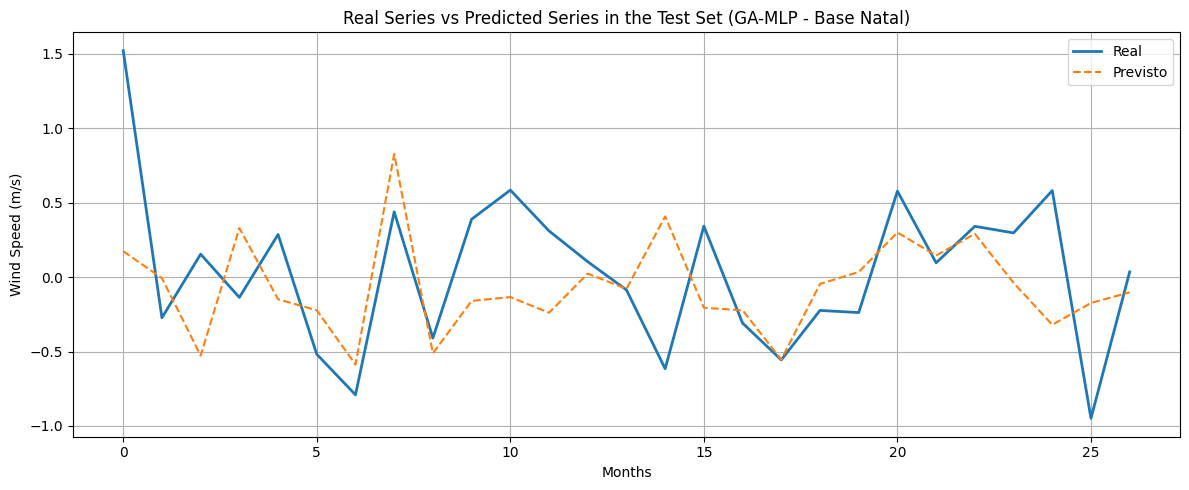

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_nat.shape[0]):
    x = X_test_nat[i,:,0]               # vetor de 12 valores
    preds.append(mlp_predict(best_model_ga_mlp_nat, x))
y_pred_ga_mlp_nat = np.array(preds).reshape(-1)

# desnormalizar as predições e o target
y_pred_ga_mlp_real_nat = scaler_nat.inverse_transform(y_pred_ga_mlp_nat.reshape(-1, 1))
y_test_real_nat = scaler_nat.inverse_transform(y_test_nat.reshape(-1, 1))

# plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_nat.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_mlp_real_nat.flatten(), label="Previsto", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-MLP - Base Natal)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_test_ga_mlp_nat  = mean_squared_error(y_test_real_nat, y_pred_ga_mlp_real_nat)
print(f"MSE test (GA-MLP - Base Natal): {mse_test_ga_mlp_nat :.4f}")

MSE test (GA-MLP - Base Natal): 0.2687


In [ ]:
# salva o array
np.save('y_pred_ga_mlp_real_nat.npy', y_pred_ga_mlp_real_nat)

###### GA-Elman

c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Erike Simon\evornn\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not p

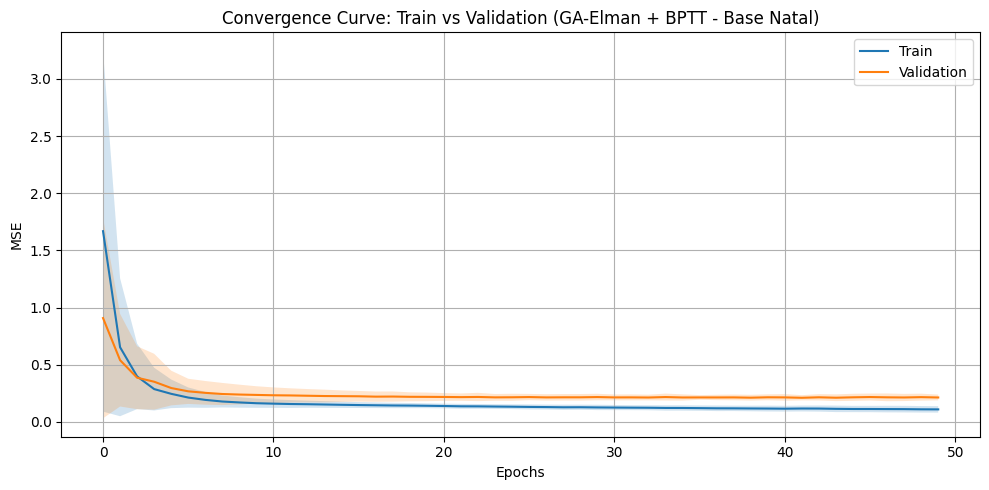


GA-Elman + BPTT training time (base Natal) : 7 minuts and 2 seconds.


In [ ]:
start_time = time.time()

resultados_ga_rnn_nat = ga_train_elman(
    X_train=X_train_nat,
    y_train=y_train_nat,
    X_val=X_val_nat,
    y_val=y_val_nat,
    X_test=X_test_nat,
    y_test=y_test_nat,
    pop_size=30,
    generations=20,
    n_execucao=30,
    n_epocas=50
)

(mse_medio_treino, mse_std_treino, mse_medio_val, mse_std_val, best_model_ga_rnn_nat, best_fitness_ga_rnn_nat, test_mses_ga_rnn_nat) = resultados_ga_rnn_nat

log_results("Natal", "GA_Elman_bptt", test_mses_ga_rnn_nat) # salva os MSEs das 30 execuções

# Plotagem da curva de convergência com incerteza
plt.figure(figsize=(10, 5))
plt.plot(mse_medio_treino, label="Train")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_treino - mse_std_treino, mse_medio_treino + mse_std_treino, alpha=0.2)

plt.plot(mse_medio_val, label="Validation")
plt.fill_between(range(len(mse_medio_treino)), mse_medio_val - mse_std_val, mse_medio_val + mse_std_val, alpha=0.2)

plt.title("Convergence Curve: Train vs Validation (GA-Elman + BPTT - Base Natal)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end_time = time.time()

elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"\nGA-Elman + BPTT training time (base Natal) : {minutes} minuts and {seconds} seconds.")

In [ ]:
print('GA-Elman + BPTT - Base Natal:')
print(f"\nMSE final training : {round(mse_medio_treino[-1], 4)} +- {round(mse_std_treino[-1], 4)} \nMSE final validation: {round(mse_medio_val[-1], 4)} +- {round(mse_std_val[-1], 4)}")
print(f"\nBest MSE validation: {best_fitness_ga_rnn_nat :.4}")

GA-Elman + BPTT - Base Natal:

MSE final training : 0.1089 +- 0.0282 
MSE final validation: 0.213 +- 0.0253

Best MSE validation: 0.1746


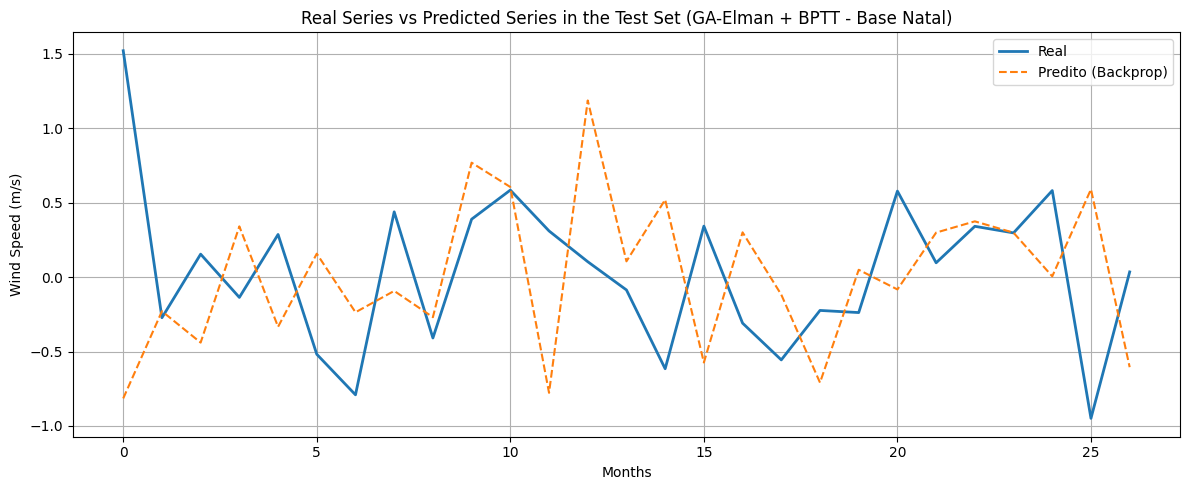

In [ ]:
# fazer as predições com base no melhor modelo GA-MLP
preds = []
for i in range(X_test_nat.shape[0]):
    x = X_test_nat[i,:,0]               # vetor de 12 valores
    preds.append(elman_predict(best_model_ga_rnn_nat, x))
y_pred_ga_rnn_nat = np.array(preds).reshape(-1)

# Inversão da normalização
y_pred_ga_rnn_real_nat = scaler_nat.inverse_transform(y_pred_ga_rnn_nat.reshape(-1, 1))
y_test_real_nat = scaler_nat.inverse_transform(y_test_nat.reshape(-1, 1))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test_real_nat.flatten(), label="Real", linewidth=2)
plt.plot(y_pred_ga_rnn_real_nat.flatten(), label="Predito (Backprop)", linestyle='--')
plt.title("Real Series vs Predicted Series in the Test Set (GA-Elman + BPTT - Base Natal)")
plt.xlabel("Months")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
mse_teste_ga_rnn_nat = mean_squared_error(y_test_real_nat, y_pred_ga_rnn_real_nat)

print('GA-Elman Network + BPTT - Base Natal')
print(f"\nMSE test: {mse_teste_ga_rnn_nat:.4f}")

GA-Elman Network + BPTT - Base Natal

MSE test: 0.6152


In [ ]:
# salva o array
np.save('y_pred_ga_elman_real_nat.npy', y_pred_ga_rnn_real_nat)

###### Plot Geral (Natal)

In [ ]:
# carrega das predições para Natal
y_pred_evornn_real_nat = np.load('y_pred_evornn_real_nat.npy')
y_pred_bptt_real_nat = np.load('y_pred_bptt_real_nat.npy')
y_pred_ga_mlp_real_nat = np.load('y_pred_ga_mlp_real_nat.npy')
y_pred_ga_elman_real_nat = np.load('y_pred_ga_elman_real_nat.npy')

#y_test_real_for = scaler_for.inverse_transform(y_test_for)

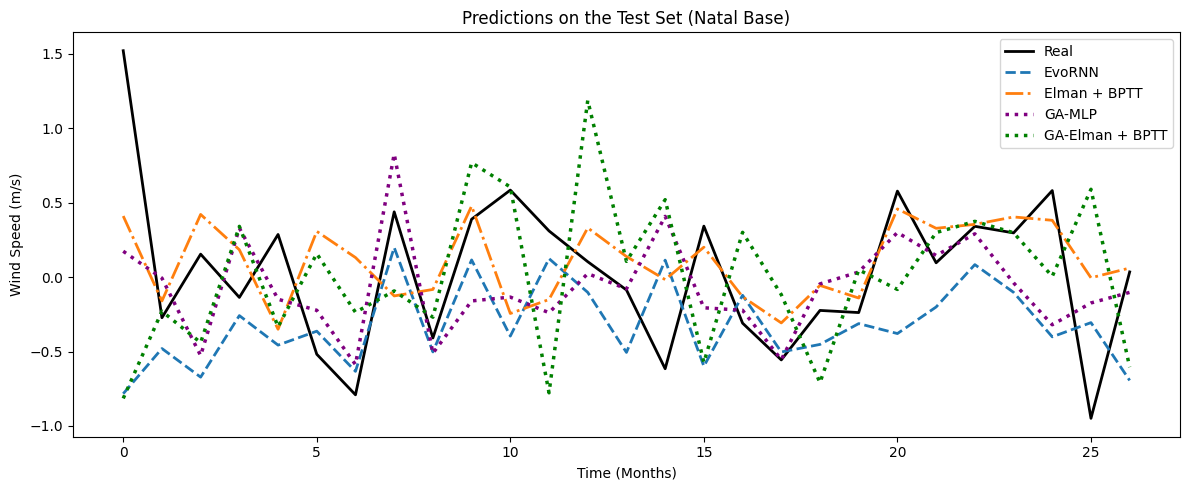

In [ ]:
plt.figure(figsize=(12, 5))

# Série real
plt.plot(y_test_real_nat.flatten(), label="Real", linewidth=2, color='black')

# Previsões
plt.plot(y_pred_evornn_real_nat.flatten(), label="EvoRNN", linestyle='--', linewidth=2)
plt.plot(y_pred_bptt_real_nat.flatten(), label="Elman + BPTT", linestyle='-.', linewidth=2)
plt.plot(y_pred_ga_mlp_real_nat, label="GA-MLP", linestyle=':', linewidth=2.5, color='purple')
plt.plot(y_pred_ga_elman_real_nat, label="GA-Elman + BPTT", linestyle=':', linewidth=2.5, color='green')

plt.title("Predictions on the Test Set (Natal Base)")
plt.xlabel("Time (Months)")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

##### Testes de hipótese

(90, 4)
               meanrank    median       mad  ci_lower  ci_upper effect_size  \
Elman_bptt     1.755556  0.119689  0.013801     0.112  0.133561         0.0   
GA_MLP         2.155556  0.135892   0.03024  0.114454  0.165543   -0.464951   
GA_Elman_bptt  2.911111  0.167373  0.043146  0.133482  0.204825   -1.004096   
EvoRNN         3.177778  0.158729  0.048453  0.129768  0.214772   -0.739174   

                magnitude effect_size_above magnitude_above  
Elman_bptt     negligible               0.0      negligible  
GA_MLP              small         -0.464951           small  
GA_Elman_bptt       large         -0.569949          medium  
EvoRNN             medium          0.127087      negligible  
The statistical analysis was conducted for 4 populations with 90 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations Elman_bptt (p=0.000), GA_MLP (p=0.003), GA_Elman_bptt (p=0.

<Axes: >

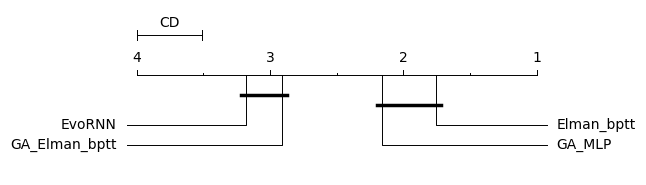

In [ ]:
from autorank import autorank, create_report, plot_stats

# 1) Carrega o CSV único com as duas bases
df = pd.read_csv("results_log.csv")

# 2) pivot para wide, index = (base,run), colunas = model
df_wide = (
    df
    .pivot(index=['base','run'],    # cada par (base,run) vira uma linha
           columns='model',         # cada modelo vira uma coluna
           values='mse')            # o conteúdo é o mse
)

# 3) alimentar o autorank
#    - order='ascending' pois menor MSE = melhor rank
result = autorank(df_wide,
                 alpha=0.05,
                 verbose=False,
                 order='ascending')

# 4) gerar relatório texto
print(create_report(result))

# 5) desenhar diagrama de CD
plot_stats(result)